# PAPER PATHCH with Ibex Risc-V#%% md


## Load data

### Load plaintexts

In [1]:
# Initialize an array to store the extracted values
hex_arrays = []
path="/media/abish/Extreme Pro/vcdfull/" #vcdfull/"
# Open the file and process each line
with open(path+"plaintexts.txt", "r") as file:
    for line in file:
        # Split the line by spaces and extract the hex values (ignoring the label before the colon)
        parts = line.strip().split(":")
        if len(parts) == 2:
            hex_values = parts[1].strip().split()
            hex_arrays.append(hex_values)

### Load Trace data

In [2]:
import numpy as np
import os

# Directory containing the data files
data_directory = path+"Result/"
number_of_traces = 49
# Initialize a list to store all the numpy arrays
data_arrays = []

# Iterate through all 422 files
for i in range(1, number_of_traces+1):  # From 1 to 422
    file_name = f"plot_data_check_{i}.data"
    file_path = os.path.join(data_directory, file_name)

    # Initialize a list to store the second values for the current file
    second_values = []

    # Read the file
    with open(file_path, "r") as file:
        for line in file:
            # Ignore comment lines starting with '#'
            if line.startswith("#"):
                continue

            # Split the line into two values
            parts = line.strip().split()
            if len(parts) == 2:
                # Extract the second value
                second_values.append(float(parts[1]))

    # Convert the list of second values to a NumPy array and store it
    data_arrays.append(np.array(second_values))

# Now `data_arrays` contains 422 NumPy arrays, each corresponding to one file.
# Example: Print the shape of the first array to verify
print(f"First array shape: {np.shape(data_arrays)}")
print(f"First array shape: {data_arrays[1].shape}")

First array shape: (49, 39943)
First array shape: (39943,)


### Convert data + remove last value of traces

In [3]:
number_of_traces=49
trace_arrayxy= np.array(data_arrays)[:, :-1] #remove last value of traces
trace_arrayx=trace_arrayxy[:number_of_traces]
textin_arraycc=hex_arrays[:number_of_traces]
textin_array = [[int(value, 16) for value in hex_array] for hex_array in textin_arraycc] # convert to hex
print(f"textin_array array shape: {np.shape(textin_array)}")
print(f"trace_arrayx array shape: {np.shape(trace_arrayx)}")

textin_array array shape: (49, 16)
trace_arrayx array shape: (49, 39942)


## CPA

In [4]:
from tqdm.notebook import trange
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
from Crypto.Cipher import AES  # PyCryptodome library for AES verification
import time


sbox = [
    # 0    1    2    3    4    5    6    7    8    9    a    b    c    d    e    f
    0x63,0x7c,0x77,0x7b,0xf2,0x6b,0x6f,0xc5,0x30,0x01,0x67,0x2b,0xfe,0xd7,0xab,0x76, # 0
    0xca,0x82,0xc9,0x7d,0xfa,0x59,0x47,0xf0,0xad,0xd4,0xa2,0xaf,0x9c,0xa4,0x72,0xc0, # 1
    0xb7,0xfd,0x93,0x26,0x36,0x3f,0xf7,0xcc,0x34,0xa5,0xe5,0xf1,0x71,0xd8,0x31,0x15, # 2
    0x04,0xc7,0x23,0xc3,0x18,0x96,0x05,0x9a,0x07,0x12,0x80,0xe2,0xeb,0x27,0xb2,0x75, # 3
    0x09,0x83,0x2c,0x1a,0x1b,0x6e,0x5a,0xa0,0x52,0x3b,0xd6,0xb3,0x29,0xe3,0x2f,0x84, # 4
    0x53,0xd1,0x00,0xed,0x20,0xfc,0xb1,0x5b,0x6a,0xcb,0xbe,0x39,0x4a,0x4c,0x58,0xcf, # 5
    0xd0,0xef,0xaa,0xfb,0x43,0x4d,0x33,0x85,0x45,0xf9,0x02,0x7f,0x50,0x3c,0x9f,0xa8, # 6
    0x51,0xa3,0x40,0x8f,0x92,0x9d,0x38,0xf5,0xbc,0xb6,0xda,0x21,0x10,0xff,0xf3,0xd2, # 7
    0xcd,0x0c,0x13,0xec,0x5f,0x97,0x44,0x17,0xc4,0xa7,0x7e,0x3d,0x64,0x5d,0x19,0x73, # 8
    0x60,0x81,0x4f,0xdc,0x22,0x2a,0x90,0x88,0x46,0xee,0xb8,0x14,0xde,0x5e,0x0b,0xdb, # 9
    0xe0,0x32,0x3a,0x0a,0x49,0x06,0x24,0x5c,0xc2,0xd3,0xac,0x62,0x91,0x95,0xe4,0x79, # a
    0xe7,0xc8,0x37,0x6d,0x8d,0xd5,0x4e,0xa9,0x6c,0x56,0xf4,0xea,0x65,0x7a,0xae,0x08, # b
    0xba,0x78,0x25,0x2e,0x1c,0xa6,0xb4,0xc6,0xe8,0xdd,0x74,0x1f,0x4b,0xbd,0x8b,0x8a, # c
    0x70,0x3e,0xb5,0x66,0x48,0x03,0xf6,0x0e,0x61,0x35,0x57,0xb9,0x86,0xc1,0x1d,0x9e, # d
    0xe1,0xf8,0x98,0x11,0x69,0xd9,0x8e,0x94,0x9b,0x1e,0x87,0xe9,0xce,0x55,0x28,0xdf, # e
    0x8c,0xa1,0x89,0x0d,0xbf,0xe6,0x42,0x68,0x41,0x99,0x2d,0x0f,0xb0,0x54,0xbb,0x16  # f
]

def aes_internal(inputdata, key):
    return sbox[inputdata ^ key]

HW = [bin(n).count("1") for n in range(0, 256)]


def mean(X):
    return np.sum(X, axis=0)/len(X)

def std_dev(X, X_bar):
    return np.sqrt(np.sum((X-X_bar)**2, axis=0))

def cov(X, X_bar, Y, Y_bar):
    return np.sum((X-X_bar)*(Y-Y_bar), axis=0)
# Function to compute KL Divergence for normal distributions
def kl_divergence(mu_x, sigma_x, mu_y, sigma_y):
    return ((mu_x - mu_y)**2) / (2 * sigma_y**2) + (sigma_x**2) / (2 * sigma_y**2) - 0.5 + np.log(sigma_y / sigma_x)

starttime =time.time()
# Correct key for comparison
correct_key = [0x2b, 0x7e, 0x15, 0x16, 0x28, 0xae, 0xd2, 0xa6, 0xab, 0xf7, 0x15, 0x88, 0x09, 0xcf, 0x4f, 0x3c]


t_bar = np.sum(trace_arrayx, axis=0)/len(trace_arrayx)
o_t = np.sqrt(np.sum((trace_arrayx - t_bar)**2, axis=0))

cparefs = [0] * 16 #put your key byte guess correlations here
bestguess = [0] * 16 #put your key byte guesses here
startt= time.time()
for bnum in trange(0, 16):
    maxcpa = [0] * 256
    for kguess in range(0, 256):
        hws = np.array([[HW[aes_internal(textin[bnum],kguess)] for textin in textin_array]]).transpose()
        hws_bar = mean(hws)
        o_hws = std_dev(hws, hws_bar)
        correlation = cov(trace_arrayx, t_bar, hws, hws_bar)
        cpaoutput = correlation/(o_t*o_hws)
        maxcpa[kguess] = max(abs(cpaoutput))
    bestguess[bnum] = np.argmax(maxcpa)
    cparefs[bnum] = max(maxcpa)
print("Best Key Guess: ", end="")
for b in bestguess: print("%02x " % b, end="")
print("\n", cparefs)
endd= time.time()
elapsed_time = endd - startt
print(f"Elapsed time: {elapsed_time:.5f} seconds")
if bestguess == correct_key:
        print("Correct key found!")
        print(f"time is {time.time() - starttime} s")
else:
    differences = [i for i, (a, b) in enumerate(zip(bestguess, correct_key)) if a != b]
    print(f"Correct key not found! Differences at indices: {differences}")
    for i in differences:
        print(f"Index {i}: bestguess = {bestguess[i]}, correct_key = {correct_key[i]}")

  0%|          | 0/16 [00:00<?, ?it/s]

/tmp/ipykernel_18654/4224726971.py:65: RuntimeWarning: invalid value encountered in divide
  cpaoutput = correlation/(o_t*o_hws)


Best Key Guess: 2b 7e 15 16 28 ae d2 a6 ab f7 15 88 09 cf 4f 3c 
 [np.float64(0.9005951711284568), np.float64(0.9073995459248215), np.float64(0.7422845038351988), np.float64(0.7358987046540169), np.float64(0.8225621703114666), np.float64(0.9749571661086154), np.float64(0.9159853266932023), np.float64(0.9151133007285774), np.float64(0.9883056751521787), np.float64(0.8543099713955182), np.float64(0.9845731354365073), np.float64(0.8944846705428926), np.float64(0.8595200183653571), np.float64(0.8442421739287367), np.float64(0.8926372090345506), np.float64(0.8745528794337664)]
Elapsed time: 29.31004 seconds
Correct key found!
time is 29.316996097564697 s


## Compute Sensetive moment:

Peak correlation for first byte 0x2b is 0.9006 at sample index 11357


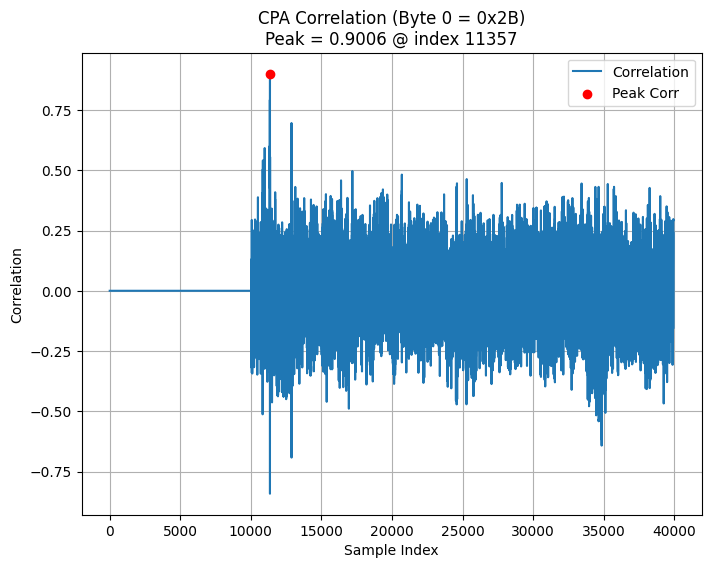

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -- Suppose the correct key for the first byte is 0x2b:
correct_key_first_byte = 0x2b
select_byte = 0  # We'll analyze byte 0
textin_array = np.array(textin_array)

# 1) Compute the hypothetical power usage (HW of SBox output) for that known subkey:
#    textin_array shape => (num_traces, 16), so textin_array[:, select_byte] is all traces' plaintext for that byte.
hws = np.array([HW[aes_internal(pt_byte, correct_key_first_byte)]
                for pt_byte in textin_array[:, select_byte]])

# 2) Convert to column vector if needed
hws = hws.reshape(-1, 1)

# 3) Compute correlation across time
hws_bar = mean(hws)
o_hws   = std_dev(hws, hws_bar)

correlation = cov(trace_arrayx, t_bar, hws, hws_bar)
with np.errstate(divide='ignore', invalid='ignore'):
    cpaoutput = correlation / (o_t * o_hws)
cpaoutput = np.nan_to_num(cpaoutput)  # Replace nan/inf with 0


# 4) Find the peak correlation index & value
peak_idx = np.argmax(np.abs(cpaoutput))
peak_val = cpaoutput[peak_idx]

print(f"Peak correlation for first byte 0x2b is {peak_val:.4f} at sample index {peak_idx}")

# 5) Plot correlation vs. sample index
plt.figure(figsize=(8,6))
plt.plot(cpaoutput, label='Correlation')
plt.scatter(peak_idx, peak_val, color='red', label='Peak Corr', zorder=5)
plt.title(f"CPA Correlation (Byte 0 = 0x2B)\nPeak = {peak_val:.4f} @ index {peak_idx}")
plt.xlabel("Sample Index")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.show()


ValueError: x and y must have same first dimension, but have shapes (4000,) and (0,)

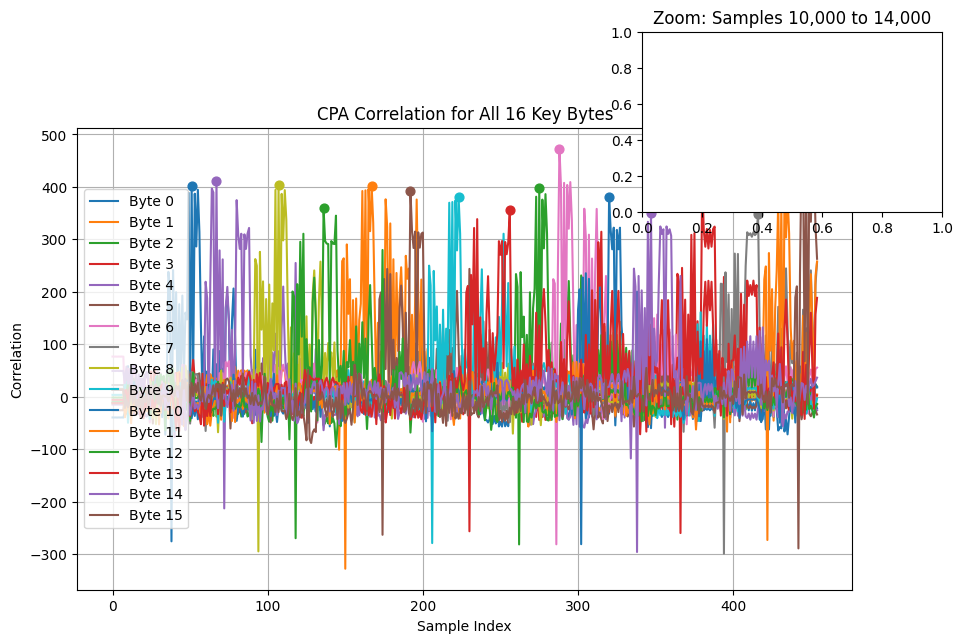

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Example: 16-byte correct key
correct_key = [
    0x2b, 0x7e, 0x15, 0x16,
    0x28, 0xae, 0xd2, 0xa6,
    0xab, 0xf7, 0x15, 0x88,
    0x09, 0xcf, 0x4f, 0x3c
]

num_traces, num_samples = trace_arrayx.shape
textin_array = np.array(textin_array)

# Precompute stats for measured traces
t_bar = np.mean(trace_arrayx, axis=0)
o_t   = np.std(trace_arrayx, axis=0, ddof=1)

# cpa_all => shape (16, num_samples) for correlation of each byte
cpa_all = np.zeros((16, num_samples))

for byte_idx in range(16):
    # Compute hypothetical HW for each trace
    hw_array = np.array([
        HW[aes_internal(pt_byte, correct_key[byte_idx])]
        for pt_byte in textin_array[:, byte_idx]
    ])
    hw_array = hw_array.reshape(-1, 1)

    # Compute mean & std
    hw_mean = np.mean(hw_array)
    hw_std  = np.std(hw_array, ddof=1)

    # Compute covariance => shape (num_samples,)
    covariance = cov(trace_arrayx, t_bar, hw_array, hw_mean)

    # Correlation
    with np.errstate(divide='ignore', invalid='ignore'):
        cpa = covariance / (o_t * hw_std)
    cpa = np.nan_to_num(cpa)

    cpa_all[byte_idx, :] = cpa

############################
# Main Figure with Full Plot
############################
fig, ax_main = plt.subplots(figsize=(10, 6))

for byte_idx in range(16):
    data_full = cpa_all[byte_idx, :]
    line, = ax_main.plot(data_full, label=f"Byte {byte_idx}")

    # Mark global peak (absolute)
    peak_idx_full = np.argmax(np.abs(data_full))
    peak_val_full = data_full[peak_idx_full]

    # Highlight the peak
    peak_color = line.get_color()
    ax_main.scatter(peak_idx_full, peak_val_full, s=40, color=peak_color, zorder=5)

ax_main.set_title("CPA Correlation for All 16 Key Bytes")
ax_main.set_xlabel("Sample Index")
ax_main.set_ylabel("Correlation")
ax_main.grid(True)
ax_main.legend(bbox_to_anchor=(0, 0.5), loc="center left")  # Legend on left side

###################################
# Rectangle to Highlight Zoom Area
###################################
start_idx = 10000
end_idx   = 14000

# Get current y-limits (after plotting)
ymin, ymax = ax_main.get_ylim()

# Create a rectangle from x=start_idx..end_idx and y=ymin..ymax
rect_width  = end_idx - start_idx
rect_height = ymax - ymin

# Add the rectangle to highlight that region
zoom_rect = patches.Rectangle(
    (start_idx, ymin),    # (x, y) start
    rect_width,           # width
    rect_height,          # height
    linewidth=5,
    edgecolor='red',
    fill=False            # just outline
)
ax_main.add_patch(zoom_rect)

###################################
# Inset Zoom: indices 11,000 - 13,000
###################################
ax_zoom = fig.add_axes([0.69, 0.74, 0.3, 0.3])  # x0, y0, width, height in fig coords
ax_zoom.set_title("Zoom: Samples 10,000 to 14,000")

for byte_idx in range(16):
    data_zoom = cpa_all[byte_idx, start_idx:end_idx]
    line_zoom, = ax_zoom.plot(np.arange(start_idx, end_idx), data_zoom)

    # Mark peak (absolute) in the zoom region
    local_peak_idx = np.argmax(np.abs(data_zoom))
    peak_val_zoom = data_zoom[local_peak_idx]
    global_peak_idx = start_idx + local_peak_idx

    peak_color = line_zoom.get_color()
    ax_zoom.scatter(global_peak_idx, peak_val_zoom, s=40, color=peak_color, zorder=5)

ax_zoom.set_xlim(start_idx, end_idx)
#ax_zoom.set_xlabel("Index")
#ax_zoom.set_ylabel("Corr")
ax_zoom.grid(True)
mark_inset(ax_main, ax_zoom, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()
plt.savefig("plot_data_check_1.png")
# Save as a cropped PDF with transparent background
plt.tight_layout()

fig.savefig("PATH_2x3_plot2.pdf", bbox_inches="tight", transparent=True)

# Save as a cropped SVG with transparent background
fig.savefig("PATH_2x3_plot2.svg", bbox_inches="tight", transparent=True)
fig.savefig("PATH_2x3_plot2.png", bbox_inches="tight", transparent=True)


## Compute sensetive sensetive_moments and Regions

In [48]:
sensetive_moments = np.zeros((16, 1))
sensetive_momentsval =np.zeros((16, 20))
for byte_idx in range(16):
    data_zoom = cpa_all[byte_idx, :]
    local_peak_idx = np.argmax(np.abs(data_zoom))
    print(f"Byte {byte_idx}: Peak correlation at index {local_peak_idx} in the zoom region")
    sensetive_moments[byte_idx] = local_peak_idx
    sensetive_momentsval[byte_idx]=(data_zoom[local_peak_idx - 10:local_peak_idx + 10])

import numpy as np
import os
sensetive_region = np.zeros((16, 2))
# Directory containing the data files
data_directory = path + "Result/"

# Initialize a list to store all the numpy arrays
data_arraystime = []

# Iterate through all 422 files

file_name = f"plot_data_check_1.data"
file_path = os.path.join(data_directory, file_name)

    # Initialize a list to store the second values for the current file
first_values = []

    # Read the file
with open(file_path, "r") as file:
    for line in file:
            # Ignore comment lines starting with '#'
        if line.startswith("#"):
            continue

            # Split the line into two values
        parts = line.strip().split()
        if len(parts) == 2:
                # Extract the second value
            first_values.append(float(parts[0]))
data_arraystime.append(np.array(first_values))

# Now `data_arrays` contains 422 NumPy arrays, each corresponding to one file.
# Example: Print the shape of the first asrray to verify
print(f"First array shape: {np.shape(data_arraystime)}")
print(f"First array shape: {data_arraystime[0].shape}")
for byte_idx in range(16):
    sensetive_region[byte_idx, 0] = data_arraystime[0][int(sensetive_moments[byte_idx] - 10)].item()
    sensetive_region[byte_idx, 1] = data_arraystime[0][int(sensetive_moments[byte_idx] + 10)].item()
    print(f"Byte {byte_idx}: Sensetive region is from {sensetive_region[byte_idx][0]} to {sensetive_region[byte_idx][1]}")
print(min(sensetive_region[:, 0]))
print(max(sensetive_region[:, 1]))

Byte 0: Peak correlation at index 51 in the zoom region
Byte 1: Peak correlation at index 167 in the zoom region
Byte 2: Peak correlation at index 275 in the zoom region
Byte 3: Peak correlation at index 380 in the zoom region
Byte 4: Peak correlation at index 67 in the zoom region
Byte 5: Peak correlation at index 192 in the zoom region
Byte 6: Peak correlation at index 288 in the zoom region
Byte 7: Peak correlation at index 416 in the zoom region
Byte 8: Peak correlation at index 107 in the zoom region
Byte 9: Peak correlation at index 223 in the zoom region
Byte 10: Peak correlation at index 320 in the zoom region
Byte 11: Peak correlation at index 435 in the zoom region
Byte 12: Peak correlation at index 136 in the zoom region
Byte 13: Peak correlation at index 256 in the zoom region
Byte 14: Peak correlation at index 347 in the zoom region
Byte 15: Peak correlation at index 444 in the zoom region
First array shape: (1, 456)
First array shape: (456,)
Byte 0: Sensetive region is fr

/tmp/ipykernel_16740/45311590.py:46: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sensetive_region[byte_idx, 0] = data_arraystime[0][int(sensetive_moments[byte_idx] - 10)].item()
/tmp/ipykernel_16740/45311590.py:47: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sensetive_region[byte_idx, 1] = data_arraystime[0][int(sensetive_moments[byte_idx] + 10)].item()


In [ ]:
import os
import re
import gc
import pickle
import warnings
import numpy as np
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.stats import pearsonr, ConstantInputWarning

###############################################################################
# (1) Single-file parser capturing both edges in a user time window
###############################################################################
def parse_vcd_file_both_edges(
    vcd_file,
    clock_signal_name="SYSCLK_P",
    start_time_ps=0,
    stop_time_ps=float('inf')
):
    """
    Parses a single VCD file in [start_time_ps..stop_time_ps):
      - We track all signals at each clock edge (both 0->1 & 1->0).
      - If a signal doesn't appear between edges, we reuse its previous value.
      - waveforms[sig_name] => list of int
      - toggles[sig_name]   => list of +1 / -1 / 0
    Returns (waveforms, toggles, edge_count)
    """

    signal_defs   = {}
    current_values= {}  # var_id -> last known '0','1', or '1010'
    waveforms     = {}
    toggles       = {}
    clock_id      = None
    last_clock_val= None

    in_dumpvars   = False
    edge_count    = 0
    current_time_ps = 0

    def ensure_sig_arrays(sig_name):
        if sig_name not in waveforms:
            waveforms[sig_name] = []
            toggles[sig_name]   = []

    with open(vcd_file, 'r') as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            # 1) parse definitions
            if line.startswith("$var"):
                parts = line.split()
                if len(parts) >= 5:
                    var_id   = parts[3]
                    sig_name = " ".join(parts[4:-1]).strip()

                    signal_defs[var_id] = sig_name
                    current_values[var_id] = 'x'
                    ensure_sig_arrays(sig_name)

                    if sig_name == clock_signal_name:
                        clock_id = var_id
                continue

            # 2) handle $dumpvars
            if line.startswith("$dumpvars"):
                in_dumpvars = True
                continue
            if line.startswith("$end") and in_dumpvars:
                in_dumpvars = False
                continue

            # 3) time marker => #<ps>
            if line.startswith('#'):
                try:
                    current_time_ps = int(line[1:])
                except ValueError:
                    current_time_ps = 0
                continue

            # skip changes outside [start_time_ps..stop_time_ps)
            if not (start_time_ps <= current_time_ps < stop_time_ps):
                continue

            # parse single-bit => "1A","0A", etc.
            m_single = re.match(r'^([01xXzZ])(\S+)$', line)
            if m_single:
                val, var_id = m_single.groups()
                val = val.lower()
                if val in ['x','z']:
                    val = '0'
                if var_id in current_values:
                    current_values[var_id] = val

                # if clock => check edge
                if var_id == clock_id:
                    new_val = int(val)
                    if last_clock_val is not None and new_val != last_clock_val:
                        # record edge
                        record_clock_edge(
                            signal_defs, current_values, waveforms, toggles, edge_count
                        )
                        edge_count += 1
                    last_clock_val = new_val
                continue

            # parse multi-bit => "b1010 A"
            m_bus = re.match(r'^b([01xXzZ]+)\s+(\S+)$', line)
            if m_bus:
                bits_str, var_id = m_bus.groups()
                bits_str = bits_str.lower().replace('x','0').replace('z','0')
                if var_id in current_values:
                    current_values[var_id] = bits_str

                if var_id == clock_id:
                    new_val_int = int(bits_str, 2)
                    if last_clock_val is not None and new_val_int != last_clock_val:
                        record_clock_edge(
                            signal_defs, current_values, waveforms, toggles, edge_count
                        )
                        edge_count += 1
                    last_clock_val = new_val_int

    return waveforms, toggles, edge_count

def record_clock_edge(signal_defs, current_values, waveforms, toggles, edge_idx):
    """
    Called each time the clock toggles. We record *all signals* in waveforms[sig_name].
    Then compute toggles => +1 if changed from the previous edge, -1 if same, 0 if first edge.
    """
    for var_id, sig_name in signal_defs.items():
        val_str = current_values.get(var_id, '0')
        # convert
        try:
            val_int = int(val_str, 2)
        except ValueError:
            if val_str in ['0','1']:
                val_int = int(val_str)
            else:
                val_int = 0

        arr = waveforms[sig_name]
        tog = toggles[sig_name]

        arr.append(val_int)
        if len(arr) == 1:
            tog.append(0)
        else:
            old_val = arr[-2]
            tog.append(+1 if val_int != old_val else -1)


###############################################################################
# (2) Parallel parse with up to 8 workers
###############################################################################
def parse_vcd_file_wrapper(args):
    """
    For each file in parallel: calls parse_vcd_file_both_edges.
    args => (vcd_file, clock_signal, start_ps, stop_ps)
    """
    vcd_file, clock_signal, start_ps, stop_ps = args
    wave, tog, edge_ct = parse_vcd_file_both_edges(
        vcd_file,
        clock_signal_name=clock_signal,
        start_time_ps=start_ps,
        stop_time_ps=stop_ps
    )
    return wave, tog, edge_ct

def parse_all_vcds_in_parallel(
    folder,
    clock_signal,
    total_files=70,
    max_workers=8,
    start_time_ps=0,
    stop_time_ps=float('inf')
):
    """
    Multi-process approach: parse vcd1..vcdN up to 8 workers, capturing signals in [start..stop).
    Returns => list of (waveforms, toggles, edge_count).
    """
    from concurrent.futures import ProcessPoolExecutor, as_completed

    filepaths = [os.path.join(folder, f"vcd{i}.vcd") for i in range(1, total_files+1)]
    tasks = []
    for i, path in enumerate(filepaths):
        tasks.append((path, clock_signal, start_time_ps, stop_time_ps))

    results = [None]*total_files

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        fut_map = {}
        for i, arg_tuple in enumerate(tasks):
            fut = executor.submit(parse_vcd_file_wrapper, arg_tuple)
            fut_map[fut] = i

        for fut in tqdm(as_completed(fut_map), total=total_files, desc="Parsing VCDs"):
            idx = fut_map[fut]
            try:
                w, t, e_ct = fut.result()
                results[idx] = (w, t, e_ct)
            except Exception as e:
                print(f"Error in {filepaths[idx]} => {e}")
                results[idx] = ({}, {}, 0)

    return results

###############################################################################
# (3) unify wave / toggles
###############################################################################
def unify_waveforms(all_parsed):
    """
    all_parsed => list of (wave_dict, tog_dict, edge_ct).
    wave_dict => { sig_name : list of int }

    unify => waveforms_dict[sig_name] => shape=(num_files, max_edges)
    """
    num_files = len(all_parsed)
    all_signals = set()
    for (wave_dict, tog_dict, e_ct) in all_parsed:
        all_signals.update(wave_dict.keys())
    all_signals = sorted(all_signals)

    waveforms_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying waveforms"):
        wave_list = []
        lengths   = []
        for (wave_dict, tog_dict, e_ct) in all_parsed:
            arr = wave_dict.get(sig_name, [])
            wave_list.append(arr)
            lengths.append(len(arr))
        max_len = max(lengths) if lengths else 0
        arr_2d = np.zeros((num_files, max_len), dtype=np.int64)
        for i in range(num_files):
            row_data = wave_list[i]
            arr_2d[i, :len(row_data)] = row_data
        waveforms_dict[sig_name] = arr_2d

    return waveforms_dict

def unify_toggles(all_parsed):
    num_files = len(all_parsed)
    all_signals = set()
    for (wave_dict, tog_dict, e_ct) in all_parsed:
        all_signals.update(tog_dict.keys())
    all_signals = sorted(all_signals)

    toggles_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying toggles"):
        tog_list = []
        lengths  = []
        for (wave_dict, tog_dict, e_ct) in all_parsed:
            arr = tog_dict.get(sig_name, [])
            tog_list.append(arr)
            lengths.append(len(arr))
        max_len = max(lengths) if lengths else 0
        arr_2d = np.zeros((num_files, max_len), dtype=np.int64)
        for i in range(num_files):
            row_data = tog_list[i]
            arr_2d[i, :len(row_data)] = row_data
        toggles_dict[sig_name] = arr_2d

    return toggles_dict

###############################################################################
# (4) Correlation over partial windows (for each byte)
###############################################################################
def compute_partial_correlations(
    waveforms_dict,
    toggles_dict,
    time_axis_len,
    sensetive_region,
    sensetive_momentsval
):
    """
    waveforms_dict[sig_name] => shape=(num_files, time_axis_len)
    toggles_dict[sig_name]   => shape=(num_files, time_axis_len)
    'time_axis_len' => e.g. max edges in that parse range

    'sensetive_region[byte_idx,0]' => start_index
     ...
    'sensetive_region[byte_idx,1]' => end_index
    'sensetive_momentsval[byte_idx]' => correlation target (shape=(end-start,) or shape=(1,)??

    We assume 'sensetive_momentsval[byte_idx]' is shape (end_idx - start_idx,) so we can do correlation.
    We'll do a standard approach for each net: slice wave or togg from [start_idx..end_idx], shape => (num_files, slice_width).
    Then we average or produce some single number?? or do we do correlation across 'num_files'?
    The question says: "we have 100 values for each net in partial range => correlation with sensetive_momentsval[byte_idx] in all 100."

    So we interpret: for each net => shape=(num_files, time_axis_len).
    We pick the columns [start_idx..end_idx], then for each row => we might do average or sum => we get 1 number per file => shape=(num_files,). Then we do correlation with sensetive_momentsval[byte_idx] => shape=(num_files,). We'll illustrate that approach.
    """

    import warnings
    from scipy.stats import pearsonr, ConstantInputWarning

    # We'll store results => { byte_idx : [ (sig_name, correlation), ... ] }
    results_per_byte = {}
    num_bytes = sensetive_region.shape[0]

    for byte_idx in range(num_bytes):
        start_idx = int(sensetive_region[byte_idx, 0])
        end_idx   = int(sensetive_region[byte_idx, 1])
        # some user might do inclusive or exclusive. We'll do [start_idx:end_idx]
        if end_idx <= start_idx:
            print(f"Warning: empty range for byte {byte_idx} => start={start_idx}, end={end_idx}")
            results_per_byte[byte_idx] = []
            continue

        target_vec = sensetive_momentsval[byte_idx]  # shape=(num_files,) or maybe (?)
        # typically shape => (num_files,). We'll assume so.

        corrs = []
        # for each net
        for sig_name, wave_2d in waveforms_dict.items():
            # wave_2d => shape (num_files, time_axis_len)
            # slice => wave_2d[:, start_idx:end_idx]
            # we want 1 number per file => let's do average across the slice
            # Then we'll get shape (num_files,)
            slice_part = wave_2d[:, start_idx:end_idx]
            # average across columns => shape=(num_files,)
            mean_per_file = np.mean(slice_part, axis=1)

            # Now correlation vs. target_vec => shape=(num_files,)
            if len(mean_per_file) != len(target_vec):
                print(f"Dimension mismatch for byte_idx={byte_idx}, net={sig_name}. Skipping.")
                continue

            # compute correlation
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConstantInputWarning)
                if np.all(mean_per_file == mean_per_file[0]) or np.all(target_vec == target_vec[0]):
                    r_val = 0.0
                else:
                    r_val, _ = pearsonr(mean_per_file, target_vec)
            corrs.append((sig_name, r_val))

        # sort
        corrs.sort(key=lambda x: abs(x[1]), reverse=True)
        results_per_byte[byte_idx] = corrs

    return results_per_byte

###############################################################################
# (5) Main usage
###############################################################################
if __name__ == "__main__":
    folder = "/media/abish/Extreme Pro/sbox_600/vcds"
    clock_signal_name = "SYSCLK_P"
    total_files = 100
    start_ps = min(sensetive_region[:, 0])  # e.g. skip first 1,000,000 ps
    stop_ps  = max(sensetive_region[:, 1]) # e.g. process until 10,000,000 ps
    # We'll do parallel parse with up to 8 workers
    max_workers = 8
    print(f"Parsing {total_files} VCDs in parallel, clock={clock_signal_name}, workers={max_workers}")
    print(f"Time window => [{start_ps}..{stop_ps})")

    # 1) parse
    all_parsed = parse_all_vcds_in_parallel(
        folder=folder,
        clock_signal=clock_signal_name,
        total_files=total_files,
        max_workers=max_workers,
        start_time_ps=start_ps,
        stop_time_ps=stop_ps
    )
    print("\nDone parsing. Now unify waveforms & toggles...")

    # 2) unify
 #   waveforms_dict = unify_waveforms(all_parsed)
  #  toggles_dict   = unify_toggles(all_parsed)

    # Suppose waveforms_dict[sig] => shape=(num_files, max_edges)
    # we store 'max_edges' in a variable
  #  time_axis_len = 0
    # find the maximum shape among signals
 #   for sig_name, arr_2d in waveforms_dict.items():
 #       if arr_2d.shape[1] > time_axis_len:
 #           time_axis_len = arr_2d.shape[1]
 #   print(f"Max edges = {time_axis_len}")



Parsing 100 VCDs in parallel, clock=SYSCLK_P, workers=8
Time window => [19612500.0..79412500.0)


Parsing VCDs: 100%|██████████| 100/100 [03:23<00:00,  2.04s/it]



Done parsing. Now unify waveforms & toggles...


Unifying waveforms:  96%|█████████▌| 8014/8344 [05:25<1:22:15, 14.96s/it]

In [37]:
import os
import re
import gc
import pickle
import warnings
import numpy as np
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.stats import pearsonr, ConstantInputWarning
import matplotlib.pyplot as plt  # for plotting


###############################################################################
# 1) Single-file parser (Clock-Based) with Time Window
###############################################################################
def parse_vcd_clock_based(
    vcd_file,
    clock_signal_name="SYSCLK_P",
    start_time_ps=0,
    stop_time_ps=float('inf'),
    clock_duration_ps=100_000,  # e.g. 100 ns
    toggles_per_cycle=2
):
    """
    1) Estimate number of clock toggles in [start_time_ps..stop_time_ps).
       N_clock_est = (stop_time_ps - start_time_ps)/clock_duration_ps * toggles_per_cycle
    2) Pre-allocate arrays of shape (N_clock_est,) for each net => signal_arrays[sig_name].
    3) Keep last_known_value for each net. As we parse lines:
       - if we see #<time_ps> outside the time window => skip
       - if net changes, we update last_known_value[sig_name]
       - if the clock toggles => current_clock_idx++ => fill all signal_arrays[...] with last_known_value
    4) Trim arrays if we used fewer toggles than estimated.

    Returns => dict { sig_name : np.array( shape=(actual_clocks,) ) }
    """
    first= False
    total_ps = max(0, stop_time_ps - start_time_ps)
    N_clock_est = int((total_ps / clock_duration_ps) * toggles_per_cycle)
    if N_clock_est < 1:
        N_clock_est = 1  # at least 1

    signal_arrays    = {}
    last_known_value = {}
    signal_defs      = {}

    current_clock_idx = -1
    clock_id          = None

    current_time_ps   = 0
    last_clock_val    = None
    in_dumpvars       = False

    def ensure_signal_array(sig_name):
        if sig_name not in signal_arrays:
            signal_arrays[sig_name]    = np.zeros(N_clock_est, dtype=int)
            last_known_value[sig_name] = 0

    with open(vcd_file, 'r') as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            # parse definitions
            if line.startswith("$var"):
                parts = line.split()
                if len(parts) >= 5:
                    var_id   = parts[3]
                    sig_name = " ".join(parts[4:-1]).strip()
                    # register net
                    signal_defs[var_id] = sig_name
                    ensure_signal_array(sig_name)
                    if sig_name == clock_signal_name:
                        clock_id = var_id
                continue

            if line.startswith("$dumpvars"):
                in_dumpvars = True
                continue
            if line.startswith("$end") and in_dumpvars:
                in_dumpvars = False
                continue

            if line.startswith('#'):
                try:
                    current_time_ps = int(line[1:])
                    if first==False:
                        #print(f"time started with={current_time_ps}") #268350000time
                        start=current_time_ps
                        first=True
                except ValueError:
                    current_time_ps = 0
                continue

            # skip if outside time window
            if not (start_time_ps <= current_time_ps < stop_time_ps):
                continue

            # single-bit => "1A", "0A", ...
            m_single = re.match(r'^([01xXzZ])(\S+)$', line)
            if m_single:
                val, var_id = m_single.groups()
                val = val.lower()
                if val in ['x','z']:
                    val = '0'
                if var_id in signal_defs:
                    sig_name = signal_defs[var_id]
                    last_known_value[sig_name] = 1 if val=='1' else 0

                if var_id == clock_id:
                    new_val = 1 if val=='1' else 0
                    if (last_clock_val is not None) and (new_val != last_clock_val):
                        current_clock_idx += 1
                        # fill arrays if we haven't exceeded capacity
                        if current_clock_idx < N_clock_est:
                            for s_name in signal_arrays.keys():
                                signal_arrays[s_name][current_clock_idx] = last_known_value[s_name]
                    last_clock_val = new_val
                continue

            # multi-bit => "b1010 A"
            m_bus = re.match(r'^b([01xXzZ]+)\s+(\S+)$', line)
            if m_bus:
                bits_str, var_id = m_bus.groups()
                bits_str = bits_str.lower().replace('x','0').replace('z','0')
                val_int = int(bits_str, 2)

                if var_id in signal_defs:
                    sig_name = signal_defs[var_id]
                    last_known_value[sig_name] = val_int

                if var_id == clock_id:
                    if (last_clock_val is not None) and (val_int != last_clock_val):
                        current_clock_idx += 1
                        if current_clock_idx < N_clock_est:
                            for s_name in signal_arrays.keys():
                                signal_arrays[s_name][current_clock_idx] = last_known_value[s_name]
                    last_clock_val = val_int

    # trim
    actual_clocks = max(0, current_clock_idx+1)
    for s_name, arr in signal_arrays.items():
        if actual_clocks < N_clock_est:
            signal_arrays[s_name] = arr[:actual_clocks]

    return signal_arrays


###############################################################################
# 2) Parallel parse wrapper
###############################################################################
def parse_vcd_clock_based_wrapper(args):
    """
    For use with ProcessPoolExecutor. 'args' => (
       vcd_file,
       clock_signal,
       start_time_ps,
       stop_time_ps,
       clock_duration_ps,
       toggles_per_cycle
    )
    """
    (vcd_file, clock_signal_name, start_ps, stop_ps, clock_dur, toggles_per_cycle) = args
    return parse_vcd_clock_based(
        vcd_file=vcd_file,
        clock_signal_name=clock_signal_name,
        start_time_ps=start_ps,
        stop_time_ps=stop_ps,
        clock_duration_ps=clock_dur,
        toggles_per_cycle=toggles_per_cycle
    )


def parse_all_vcds_in_parallel(
    folder,
    clock_signal="SYSCLK_P",
    total_files=70,
    max_workers=8,
    start_time_ps=0,
    stop_time_ps=float('inf'),
    clock_duration_ps=100_000,  # 100 ns
    toggles_per_cycle=2
):
    """
    Parallel approach:
      1) For each file => parse_vcd_clock_based(...) with user-specified times, clock dur, toggles/cycle
      2) Return a list of length = total_files, each item => { sig_name : array (actual_clocks,) }
    """
    filepaths = [os.path.join(folder, f"vcd{i}.vcd") for i in range(1, total_files+1)]
    results = [None]*total_files

    tasks = []
    for i, path in enumerate(filepaths):
        tasks.append((path, clock_signal, start_time_ps, stop_time_ps, clock_duration_ps, toggles_per_cycle))

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        fut_map = {}
        for i,arg_tuple in enumerate(tasks):
            fut = executor.submit(parse_vcd_clock_based_wrapper, arg_tuple)
            fut_map[fut] = i

        for fut in tqdm(as_completed(fut_map), total=total_files, desc="Parsing VCDs"):
            idx = fut_map[fut]
            try:
                net_arrays = fut.result()  # => dict { sig_name : np.array(...) }
                results[idx] = net_arrays
            except Exception as e:
                print(f"Error parsing {filepaths[idx]} => {e}")
                results[idx] = {}

    return results


###############################################################################
# 3) Example main
###############################################################################
if __name__ == "__main__":
    folder = "/media/abish/Extreme Pro/sbox_600/vcdssbox"#vcds"
    clock_signal_name = "SYSCLK_P"
    total_files = 600
    start_ps = min(sensetive_region[:, 0])*1000  # e.g. skip first 1,000,000 ps 268350000time
    stop_ps  = max(sensetive_region[:, 1])*1000 # e.g. process until 10,000,000 ps


    # We'll parse in parallel using the clock-based approach
    print(f"Parallel parse of {total_files} VCDs, clock={clock_signal_name}")
    print(f"Time window => [{start_ps}..{stop_ps})")

    results_all = parse_all_vcds_in_parallel(
        folder=folder,
        clock_signal=clock_signal_name,
        total_files=total_files,
        max_workers=8,
        start_time_ps=start_ps,
        stop_time_ps=stop_ps,
        clock_duration_ps=100_000,  # 100 ns
        toggles_per_cycle=2
    )

    print("Done parsing parallel.\n")

    # 'results_all[i]' => dict { sig_name : np.array of shape (actual_clocks_i,) }

    # Optionally save
    with open("vcd_clockbased_results600.pkl", "wb") as f:
        pickle.dump(results_all, f, protocol=pickle.HIGHEST_PROTOCOL)

    print("\nAll done. 'vcd_clockbased_results.pkl' has clock-based arrays for each net in each file.")



Parallel parse of 600 VCDs, clock=SYSCLK_P
Time window => [269387500.0..279712500.0)


Parsing VCDs: 100%|██████████| 600/600 [01:06<00:00,  9.07it/s]


Done parsing parallel.


All done. 'vcd_clockbased_results.pkl' has clock-based arrays for each net in each file.


In [57]:
from tqdm import tqdm
import numpy as np
import warnings
from scipy.stats import pearsonr, ConstantInputWarning

def compute_time_average_correlations(
    results_all,
    net_names,
    start_ps,
    sensetive_region,
    sensetive_momentsval
):
    """
    results_all: list of length num_files.
      - each element is a dict { net_name : np.array(shape=(N_i,)) }
        => for file i, results_all[i][net_name] is the wave array for that net
           across the entire clock domain (indices).
    net_names: sorted list of net_names across all files
    start_ps: parse start time in ps (the earliest time included in the wave arrays)
    sensetive_region: shape (num_bytes, 2), each row => [start_time_ps, end_time_ps]
    sensetive_momentsval: shape (num_bytes, num_files)
      => for each byte row, a 1D target vector of length num_files for correlation.

    We'll produce results_per_byte => { byte_idx : [ (net_name, correlation), ... ] }
    Steps:
      - for each byte_idx in [0..num_bytes-1]:
         1) convert times => clock-based indices => idx1, idx2 = (ps - start_ps)//50000
         2) for each net_name in net_names:
             * build net_profile shape=(rng,).  rng=idx2-idx1
             * for t_idx in [idx1..idx2), gather from all files => average => net_profile[t_idx - idx1]
         3) correlation net_profile vs. target_array => single float
         4) sort results by abs correlation
    Returns: dict { byte_idx : sorted list of (net_name, r_val) }
    """

    num_files  = len(results_all)
    num_bytes  = sensetive_region.shape[0]
    results_per_byte = {}

    for byte_idx in range(num_bytes):
        start_idx_ps = sensetive_region[byte_idx, 0]
        end_idx_ps   = sensetive_region[byte_idx, 1]

        # Validate time range
        if end_idx_ps <= start_idx_ps:
            print(f"Warning: empty range for byte {byte_idx} => {start_idx_ps}..{end_idx_ps}")
            results_per_byte[byte_idx] = []
            continue

        # Convert times to clock-based indices => (time_ps - start_ps)//50,000
        idx1 = int((start_idx_ps - start_ps)//50_000)
        idx2 = int((end_idx_ps   - start_ps)//50_000)
        rng = idx2 - idx1

        if rng <= 0:
            print(f"Warning: invalid slice for byte {byte_idx}, idx1={idx1}, idx2={idx2}")
            results_per_byte[byte_idx] = []
            continue

        # correlation target => shape=(rng,)
        # We assume that sensetive_momentsval[byte_idx] has length = rng
        target_arrayx = sensetive_momentsval[byte_idx,:]
        target_array = target_arrayx.reshape(10, 2).mean(axis=1)
        if len(target_array) != rng:
            print(f"Warning: mismatch in target_array length for byte {byte_idx}. "
                  f"rng={rng}, target len={len(target_array)} => skip.")
            results_per_byte[byte_idx] = []
            continue

        corrs = []

        # Add a progress bar around net_names loop
        desc_str = f"Byte {byte_idx} correlation"
        for net_name in tqdm(net_names, desc=desc_str, leave=False):
            # net_profile => shape=(rng,)
            net_profile = np.zeros(rng, dtype=np.float64)

            # For each time in [idx1..idx2)
            for local_idx, time_idx in enumerate(range(idx1, idx2)):
                # gather from all files => shape=(num_files,), then average
                row_vals = np.zeros(num_files, dtype=np.float64)
                for f_idx in range(num_files):
                    arr = results_all[f_idx].get(net_name, np.array([], dtype=int))
                    # if time_idx < len(arr), use arr[time_idx], else 0
                    if time_idx < len(arr):
                        row_vals[f_idx] = arr[time_idx]
                    else:
                        row_vals[f_idx] = 0.0
                net_profile[local_idx] = np.mean(row_vals)

            # correlation => net_profile vs target_array
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConstantInputWarning)
                if (np.all(net_profile == net_profile[0])
                    or np.all(target_array == target_array[0])):
                    r_val = 0.0
                else:
                    r_val, _ = pearsonr(net_profile, target_array)

            corrs.append((net_name, r_val))

        # sort by abs correlation
        corrs.sort(key=lambda x: abs(x[1]), reverse=True)
        results_per_byte[byte_idx] = corrs

    return results_per_byte

if __name__=="__main__":

    # gather union of net_names
    net_names_set = set()
    for d in results_all:
        net_names_set.update(d.keys())
    net_names = sorted(net_names_set)
    start_ps = min(sensetive_region[:, 0])*1000  # e.g. skip first 1,000,000 ps 268350000time
    stop_ps  = max(sensetive_region[:, 1])*1000 # e.g. process until 10,000,000 ps

    # define 'sensetive_momentsval' => shape=(num_bytes, num_files)
    # e.g. random placeholder for demonstration:
    num_bytes = sensetive_region.shape[0]

    # compute correlations
    results_per_byte = compute_time_average_correlations(
        results_all=results_all,
        net_names=net_names,
        start_ps=start_ps,
        sensetive_region=sensetive_region*1000,
        sensetive_momentsval=sensetive_momentsval
    )

    # show top 5 for each byte
    for byte_idx in range(num_bytes):
        corrs = results_per_byte[byte_idx]
        print(f"\nByte {byte_idx} top signals:")
        for rank, (net_name, r_val) in enumerate(corrs[:5], 1):
            print(f"{rank}. {net_name} => corr={r_val:.4f}")

    # optionally save fina
    print("\nAll done. 'vcd_clockbased_results.pkl' contains net arrays & correlation results!")



Byte 0 top signals:
1. instr_rdata [20] => corr=0.6167
2. n_2472 => corr=0.6167
3. n_2594 => corr=0.6167
4. n_2596 => corr=0.6167
5. n_2816 => corr=0.6167

Byte 1 top signals:
1. n_2768 => corr=-0.6492
2. n_2690 => corr=-0.6488
3. n_2887 => corr=-0.6485
4. n_2749 => corr=-0.6484
5. n_2902 => corr=-0.6479

Byte 2 top signals:
1. n_2690 => corr=-0.6998
2. n_2749 => corr=-0.6991
3. instr_addr [3] => corr=-0.6973
4. n_1157 => corr=0.6973
5. n_2709 => corr=-0.6973

Byte 3 top signals:
1. csa_tree_u_top_u_ibex_core_ex_block_i_gen_multdiv_fast_multdiv_i_add_273_69_groupi_n_394 => corr=-0.8785
2. csa_tree_u_top_u_ibex_core_ex_block_i_gen_multdiv_fast_multdiv_i_add_273_69_groupi_n_445 => corr=0.8785
3. n_3601 => corr=-0.8785
4. n_4436 => corr=-0.8785
5. csa_tree_u_top_u_ibex_core_ex_block_i_gen_multdiv_fast_multdiv_i_add_273_69_groupi_n_103 => corr=0.8785

Byte 4 top signals:
1. csa_tree_u_top_u_ibex_core_ex_block_i_gen_multdiv_fast_multdiv_i_add_273_69_groupi_n_257 => corr=-0.7494
2. csa_tree

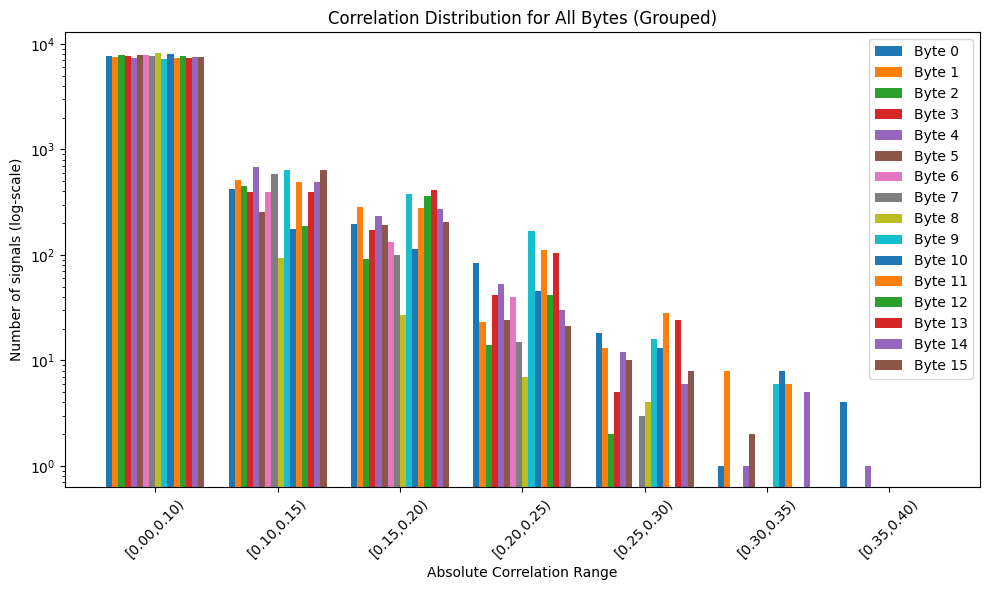

In [31]:
import numpy as np
import matplotlib.pyplot as plt

def plot_correlation_distribution_together(
    results_per_byte,
    num_bytes=16
):
    """
    results_per_byte: dict { byte_idx : [ (net_name, corr_value), ... ] }
      as returned by your correlation function.

    We define 7 bins: [0.0,0.1), [0.1,0.15), [0.15,0.2), [0.2,0.25), [0.25,0.3), [0.3,0.35), [0.35,0.4).
    We count how many signals land in each bin for each byte, then do a single grouped bar chart:
      - x-axis => the 7 bins
      - each bin => 16 bars side-by-side (one for each byte)
      - y-axis => # of signals (log scale)
    """

    # define bin edges
    bins = [0.0, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
    bin_labels = [
        "[0.00,0.10)",
        "[0.10,0.15)",
        "[0.15,0.20)",
        "[0.20,0.25)",
        "[0.25,0.30)",
        "[0.30,0.35)",
        "[0.35,0.40)"
    ]
    bin_count = len(bin_labels)

    # hist_counts[byte_idx] => shape (bin_count,)
    hist_counts = np.zeros((num_bytes, bin_count), dtype=int)

    # For each byte_idx, gather absolute correlation => bin them
    for byte_idx in range(num_bytes):
        corrs = results_per_byte.get(byte_idx, [])
        if not corrs:
            # no data => skip
            continue

        # gather absolute correlation
        abs_vals = [abs(tup[1]) for tup in corrs]

        for val in abs_vals:
            # find which bin
            for b_i in range(bin_count):
                if bins[b_i] <= val < bins[b_i+1]:
                    hist_counts[byte_idx, b_i] += 1
                    break

    # Now we do a grouped bar chart on a single figure
    x = np.arange(bin_count)  # one position per bin
    bar_width = 0.8 / num_bytes  # how wide each bar in a group

    plt.figure(figsize=(10, 6))

    for byte_idx in range(num_bytes):
        offset = (byte_idx - (num_bytes-1)/2)*bar_width
        plt.bar(
            x + offset,
            hist_counts[byte_idx, :],
            bar_width,
            label=f"Byte {byte_idx}"
        )

    plt.yscale("log")  # log scale helps if first bin is huge & others are small

    plt.xticks(x, bin_labels, rotation=45)
    plt.xlabel("Absolute Correlation Range")
    plt.ylabel("Number of signals (log-scale)")
    plt.title("Correlation Distribution for All Bytes (Grouped)")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()
plot_correlation_distribution_together(results_per_byte, num_bytes=16)

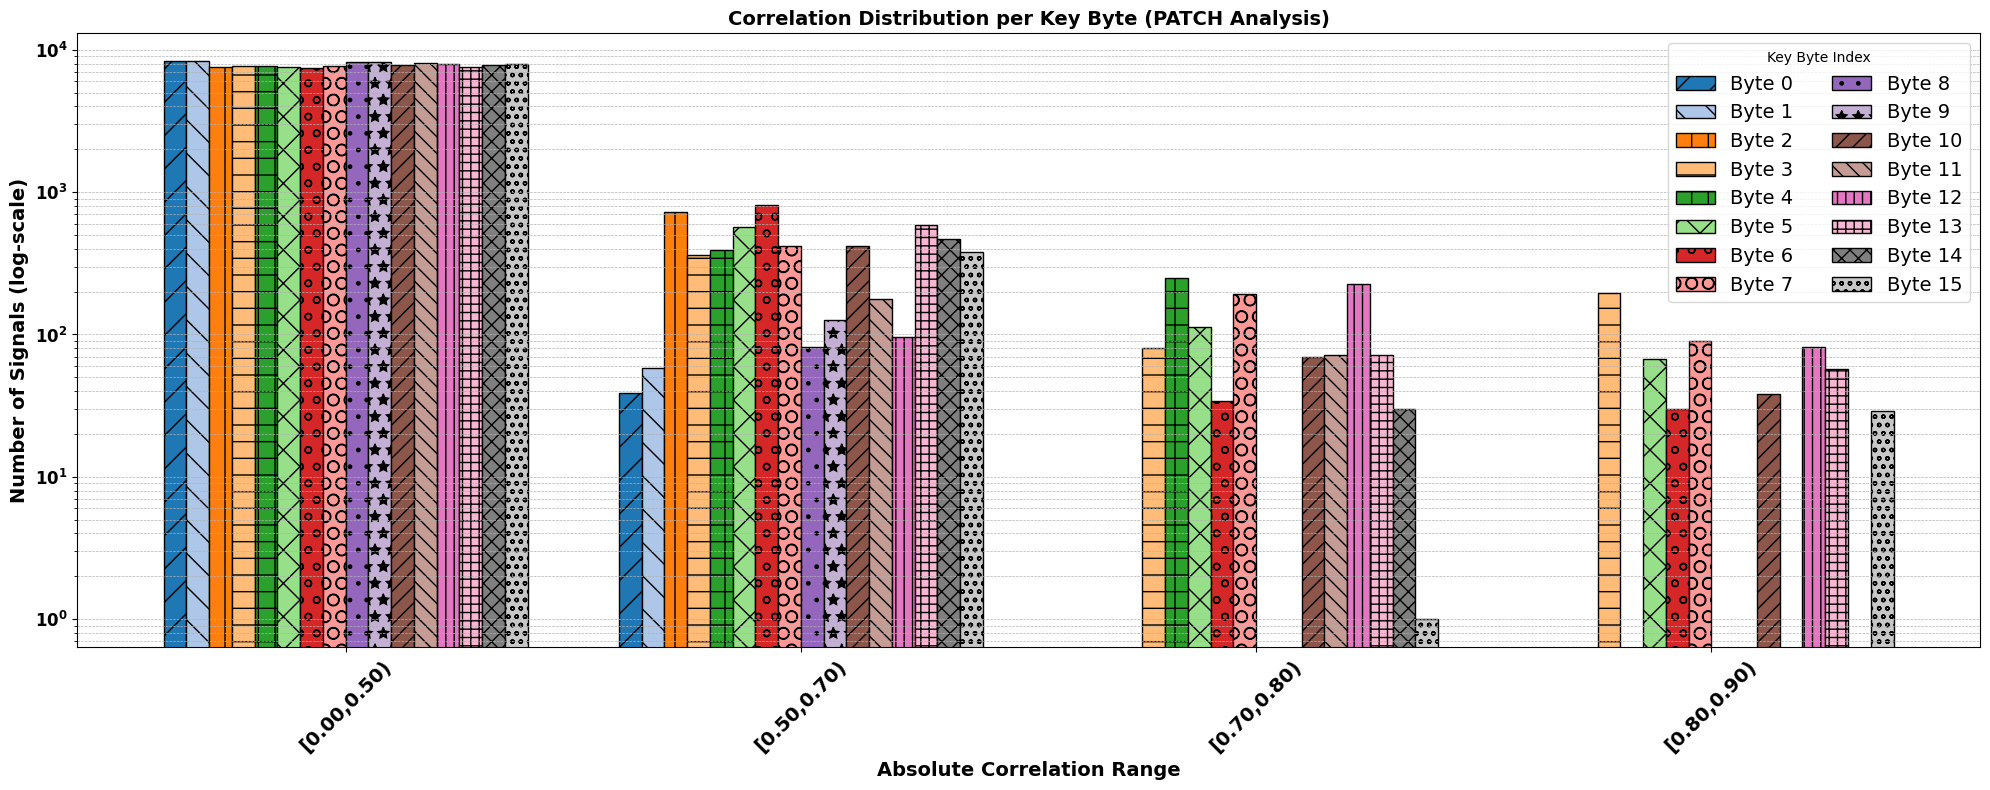

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_correlation_distribution_together(
    results_per_byte,
    num_bytes=16
):
    """
    Plot per-byte signal correlation distribution in bins:
      [0.0,0.1), [0.1,0.15), ..., [0.35,0.4)
    Combines colors + hatch patterns for print-safe + color-friendly plot.
    """

    # Define bin edges and labels
    bins = [0.0, 0.5,0.7,0.8, 0.9]
    bin_labels = [
        "[0.00,0.50)", "[0.50,0.70)", "[0.70,0.80)", "[0.80,0.90)"
    ]
    bin_count = len(bin_labels)

    # Histogram: shape=(num_bytes, bin_count)
    hist_counts = np.zeros((num_bytes, bin_count), dtype=int)

    for byte_idx in range(num_bytes):
        corrs = results_per_byte.get(byte_idx, [])
        abs_corrs = [abs(r) for _, r in corrs]
        for val in abs_corrs:
            for b_i in range(bin_count):
                if bins[b_i] <= val < bins[b_i+1]:
                    hist_counts[byte_idx, b_i] += 1
                    break

    # Define 16 distinct hatch patterns and colors
    hatch_styles = ['/', '\\', '|', '-', '+', 'x', 'o', 'O', '.', '*',
                    '//', '\\\\', '||', '++', 'xx', 'oo']
    color_palette = plt.cm.tab20.colors[:16]  # 16 distinct colors

    # Plot
    x = np.arange(bin_count)
    bar_width = 0.8 / num_bytes
    plt.figure(figsize=(20, 8))

    legend_handles = []

    for byte_idx in range(num_bytes):
        offset = (byte_idx - (num_bytes - 1) / 2) * bar_width
        bars = plt.bar(
            x + offset,
            hist_counts[byte_idx],
            width=bar_width,
            color=color_palette[byte_idx],
            edgecolor='black',
            hatch=hatch_styles[byte_idx % len(hatch_styles)],
            label=f"Byte {byte_idx}"
        )

        # Create custom legend patch
        patch = mpatches.Patch(
            facecolor=color_palette[byte_idx],
            edgecolor='black',
            hatch=hatch_styles[byte_idx % len(hatch_styles)],
            label=f"Byte {byte_idx}"
        )
        legend_handles.append(patch)

    # Log scale on y-axis
    plt.yscale("log")
    plt.yticks(fontsize=12, fontweight='bold')

    # Labels and formatting
    plt.xticks(x, bin_labels, rotation=45,fontsize=14, fontweight='bold')
    plt.xlabel("Absolute Correlation Range", fontsize=14, fontweight='bold')
    plt.ylabel("Number of Signals (log-scale)", fontsize=14, fontweight='bold')
    plt.title("Correlation Distribution per Key Byte (PATCH Analysis)", fontsize=14, fontweight='bold')
    plt.legend(
        handles=legend_handles,
        title="Key Byte Index",
        loc='upper right',
        fontsize=14,
        ncol=2
    )
    plt.tight_layout()
    plt.grid(axis='y', which='both', linestyle='--', linewidth=0.5)

    plt.savefig("byte_correlation_distribution.pdf", bbox_inches="tight", transparent=True)
    plt.savefig("byte_correlation_distribution.svg", bbox_inches="tight", transparent=True)
    plt.savefig("byte_correlation_distribution.png", bbox_inches="tight", transparent=True)
    plt.show()


plot_correlation_distribution_together(results_per_byte, num_bytes=16)

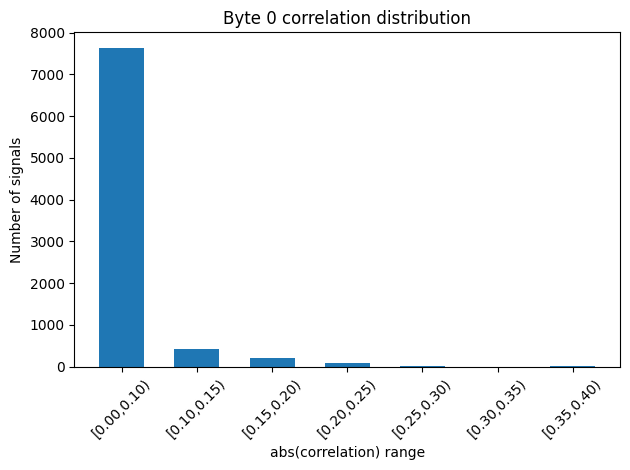

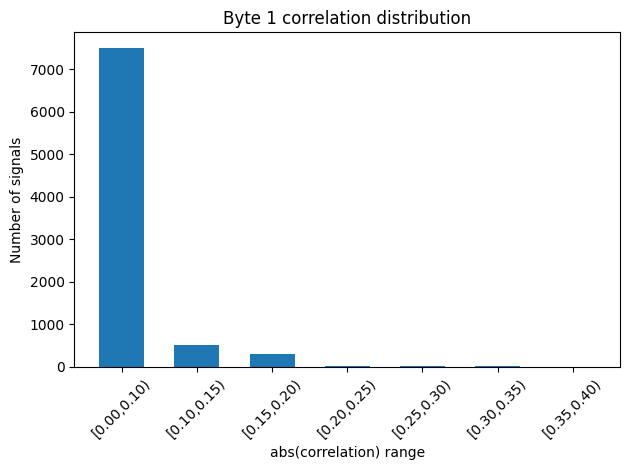

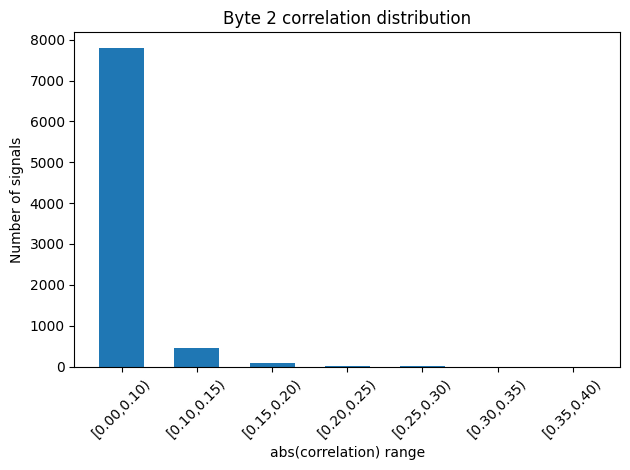

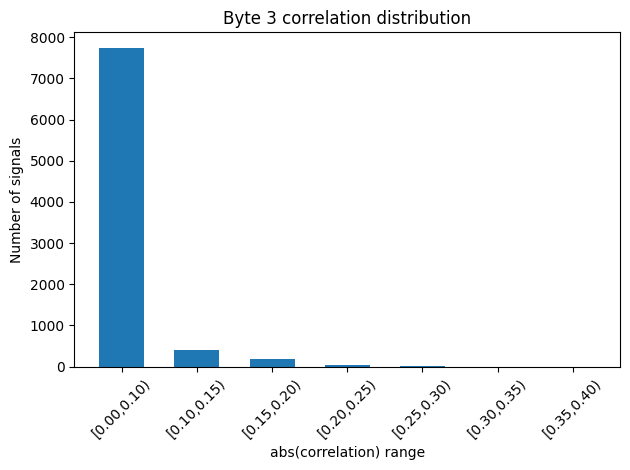

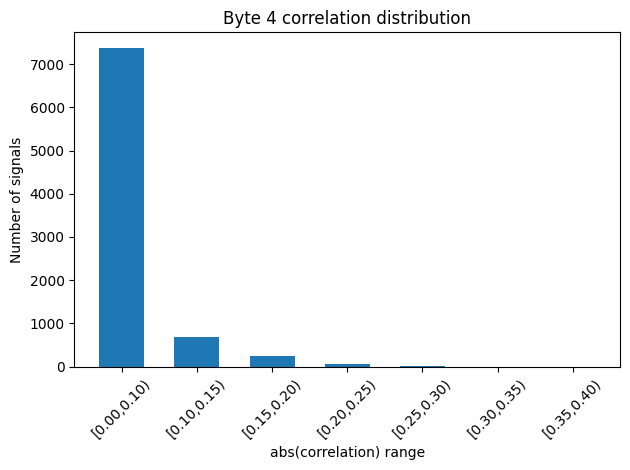

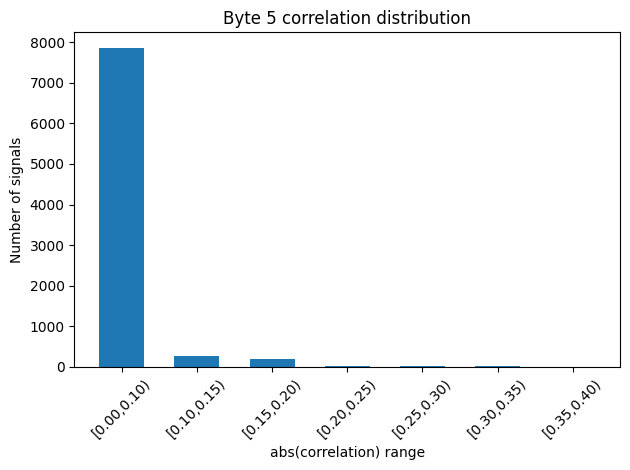

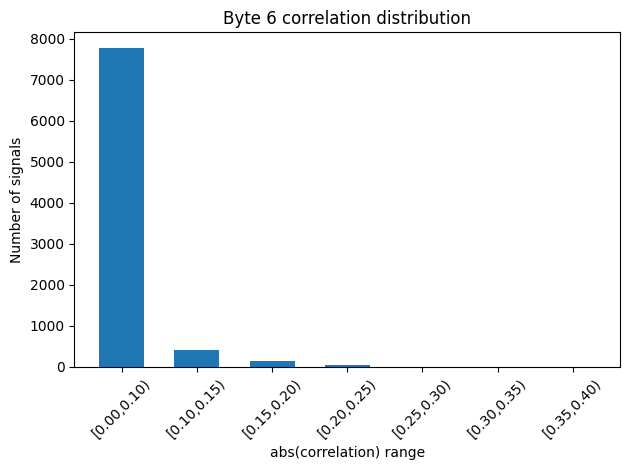

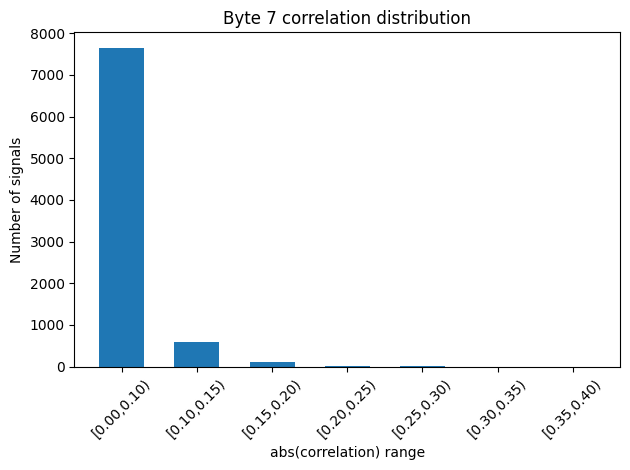

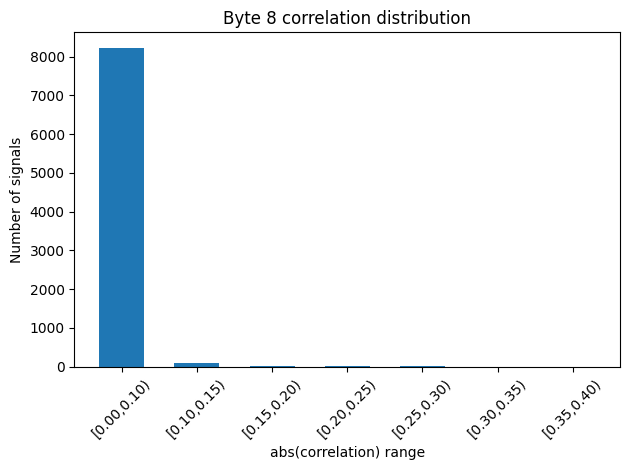

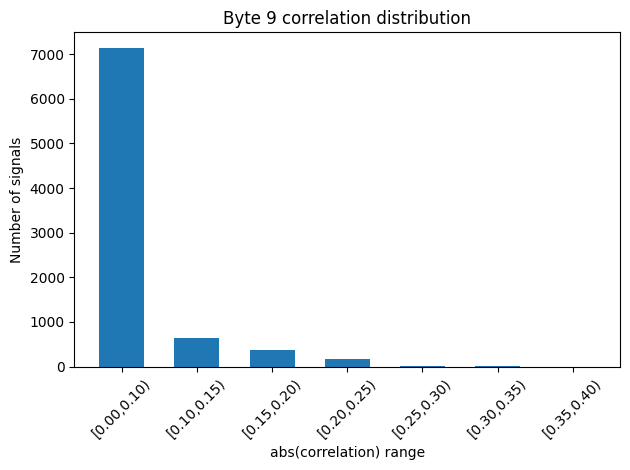

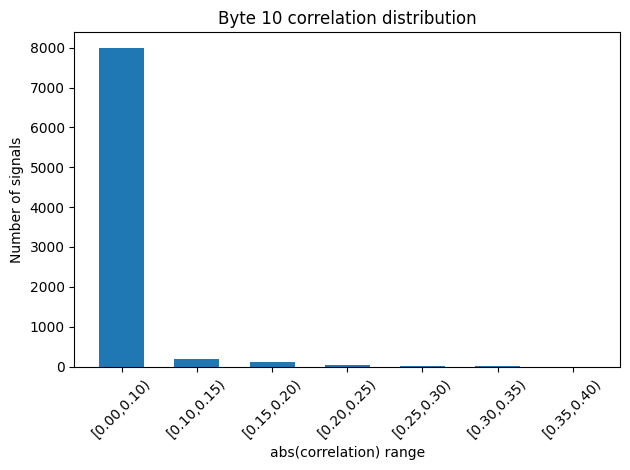

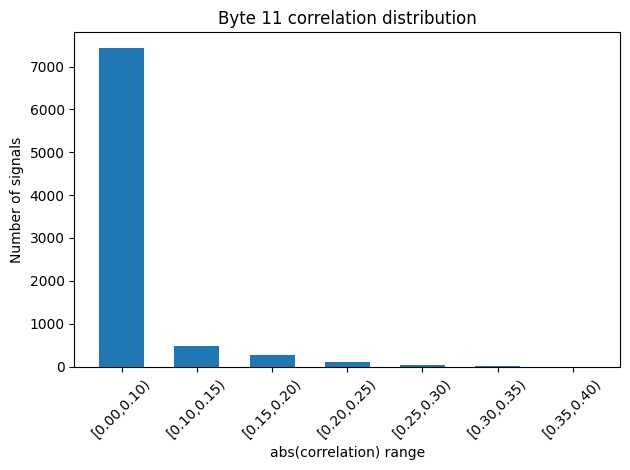

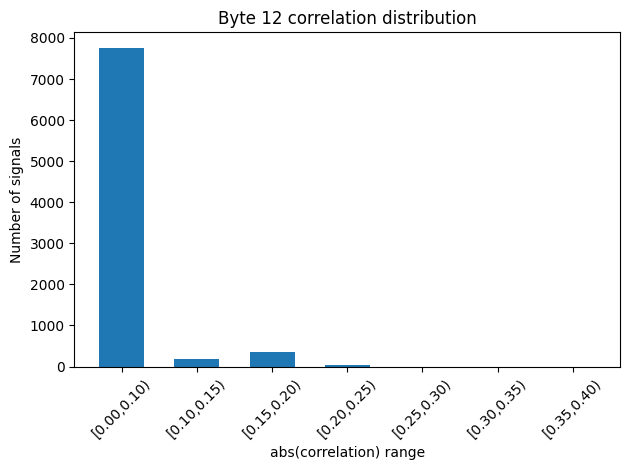

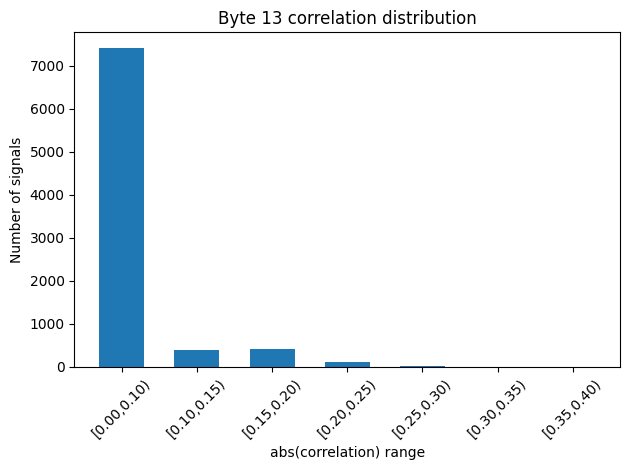

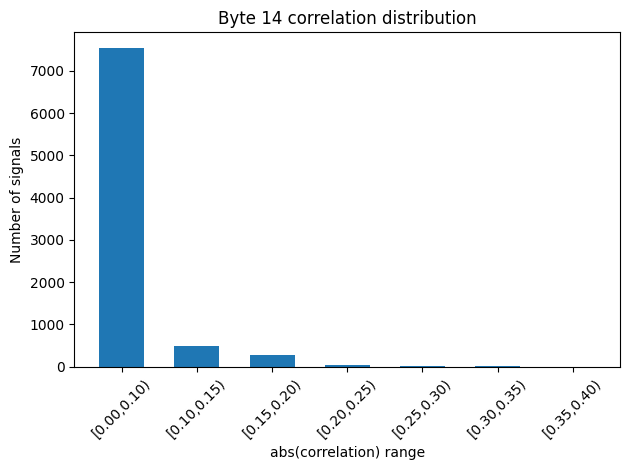

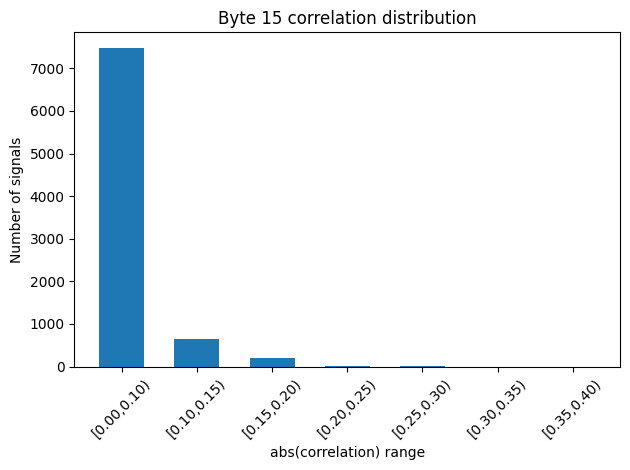

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

def plot_correlation_distribution_together(
    results_per_byte,
    num_bytes=16
):
    """
    results_per_byte: dict { byte_idx : [ (net_name, corr_value), ... ] }
      as returned by your correlation function.

    We define 7 bins: [0.0,0.1), [0.1,0.15), [0.15,0.2), [0.2,0.25), [0.25,0.3), [0.3,0.35), [0.35,0.4).
    We count how many signals land in each bin for each byte, then do a single grouped bar chart:
      - x-axis => the 7 bins
      - each bin => 16 bars side-by-side (one for each byte)
      - y-axis => # of signals (log scale)
    """

    # define bin edges
    bins = [0.0, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
    bin_labels = [
        "[0.00,0.10)",
        "[0.10,0.15)",
        "[0.15,0.20)",
        "[0.20,0.25)",
        "[0.25,0.30)",
        "[0.30,0.35)",
        "[0.35,0.40)"
    ]
    bin_count = len(bin_labels)

    # hist_counts[byte_idx] => shape (bin_count,)
    hist_counts = np.zeros((num_bytes, bin_count), dtype=int)

    # For each byte_idx, gather absolute correlation => bin them
    for byte_idx in range(num_bytes):
        corrs = results_per_byte.get(byte_idx, [])
        if not corrs:
            # no data => skip
            continue

        # gather absolute correlation
        abs_vals = [abs(tup[1]) for tup in corrs]

        for val in abs_vals:
            # find which bin
            for b_i in range(bin_count):
                if bins[b_i] <= val < bins[b_i+1]:
                    hist_counts[byte_idx, b_i] += 1
                    break

    # Now we do a grouped bar chart on a single figure
    x = np.arange(bin_count)  # one position per bin
    bar_width = 0.8 / num_bytes  # how wide each bar in a group

    plt.figure(figsize=(10, 6))

    for byte_idx in range(num_bytes):
        offset = (byte_idx - (num_bytes-1)/2)*bar_width
        plt.bar(
            x + offset,
            hist_counts[byte_idx, :],
            bar_width,
            label=f"Byte {byte_idx}"
        )

    plt.yscale("log")  # log scale helps if first bin is huge & others are small

    plt.xticks(x, bin_labels, rotation=45)
    plt.xlabel("Absolute Correlation Range")
    plt.ylabel("Number of signals (log-scale)")
    plt.title("Correlation Distribution for All Bytes (Grouped)")
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

plot_correlation_distribution(results_per_byte, num_bytes=16)


In [ ]:
import numpy as np
from scipy.stats import pearsonr, ConstantInputWarning
import warnings

def compute_correlations_for_bytes(
    results_all,
    net_names,
    start_ps,
    sensetive_region,
    sensetive_momentsval
):
    """
    results_all: list of length = num_files
      results_all[i]: dict => { net_name : np.array(shape=(N,)) }
         => clock-based samples for that net in [start_ps..stop_ps).
         => 1 sample every 50 ps (if that's how you set up parse)
    net_names: sorted list of net_names that appear in results_all
    start_ps: the start time you used for parse
    sensetive_region: shape (num_bytes, 2), each row => [start_idx_ps, end_idx_ps]
    sensetive_momentsval: shape (num_bytes, num_files)
      each row => the "target vector" for that byte
    Returns => results_per_byte: dict { byte_idx : [ (net_name, correlation), ... ] }
    """

    num_files = len(results_all)
    num_bytes = sensetive_region.shape[0]

    results_per_byte = {}

    for byte_idx in range(num_bytes):
        # time range in ps
        start_idx_ps = sensetive_region[byte_idx, 0]
        end_idx_ps   = sensetive_region[byte_idx, 1]
        if end_idx_ps <= start_idx_ps:
            print(f"Warning: empty range for byte {byte_idx} => start={start_idx_ps}, end={end_idx_ps}")
            results_per_byte[byte_idx] = []
            continue

        # compute clock-based indices => (time_ps - start_ps)/50
        idx1 = int((start_idx_ps - start_ps)//50)
        idx2 = int((end_idx_ps   - start_ps)//50)
        if idx2 <= idx1:
            print(f"Warning: invalid or empty slice for byte {byte_idx}: idx1={idx1}, idx2={idx2}")
            results_per_byte[byte_idx] = []
            continue

        # correlation target => shape (num_files,)
        target_vec = sensetive_momentsval[byte_idx,:]  # row for this byte => shape=(num_files,)

        corrs = []
        for net_name in net_names:
            # build shape => (num_files, slice_width)
            # for each file i, results_all[i][net_name] => shape=(N_i,)
            # we slice [idx1..idx2], clamp if needed
            slice_rows = []
            for file_i in range(num_files):
                net_arr = results_all[file_i].get(net_name, np.array([], dtype=int))
                # clamp idx2 if net_arr is smaller
                if idx1<0: idx1=0
                if idx2>len(net_arr): idx2=len(net_arr)
                if idx2<=idx1:
                    # no data
                    slice_rows.append(0.0)  # or you can skip
                else:
                    partial_slice = net_arr[idx1:idx2]  # shape => (slice_width,)
                    # e.g. average across that slice
                    slice_rows.append(np.mean(partial_slice))

            # now slice_rows => shape=(num_files,) => a list
            mean_per_file = np.array(slice_rows, dtype=float)

            # correlation => shape=(num_files,) vs target_vec
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConstantInputWarning)
                if (len(mean_per_file)!=len(target_vec)
                    or np.all(mean_per_file==mean_per_file[0])
                    or np.all(target_vec==target_vec[0])):
                    r_val = 0.0
                else:
                    r_val, _ = pearsonr(mean_per_file, target_vec)

            corrs.append((net_name, r_val))

        # sort by abs correlation
        corrs.sort(key=lambda x: abs(x[1]), reverse=True)
        results_per_byte[byte_idx] = corrs

    return results_per_byte


# Example usage:
# 1) Suppose we already have `results_all` => parallel parse output,
#    each results_all[i] => { net_name : np.array( shape=(N_i,) ) }
# 2) net_names => the union of all net_names we want
# 3) start_ps => the parse start time
# 4) sensetive_region => shape (16,2)
# 5) sensetive_momentsval => shape (16, num_files)


results_per_byte = compute_correlations_for_bytes(
    results_all=results_all,
    net_names=sorted_union_of_nets,
    start_ps= min(sensetive_region[:, 0]),
    sensetive_region=sensetive_region,
    sensetive_momentsval=sensetive_momentsval
)

# Then for each byte_idx in results_per_byte => sorted list of (net_name, corr)
for byte_idx in range(16):
    top10 = results_per_byte[byte_idx][:10]
    print(f"\nByte {byte_idx}: top signals:")
    for rank, (net_name, r_val) in enumerate(top10, 1):
        print(f"{rank}. {net_name} => corr={r_val:.4f}")



In [16]:
import os
import re
import gc
import pickle
import warnings
import numpy as np
from tqdm import tqdm

###############################################################################
# (1) Single-file parser
###############################################################################
def parse_vcd_file_both_edges(
    vcd_file,
    clock_signal_name="SYSCLK_P",
    start_time_ps=0,
    stop_time_ps=float('inf')
):
    """
    Parses a single VCD in a single-thread, capturing:
      - All signals, storing them at each clock edge (both 0->1 and 1->0).
      - If a signal doesn't appear in between edges, we reuse its last known value.
      - We only accept changes if current_time_ps is in [start_time_ps, stop_time_ps).

    Returns:
      waveforms: { sig_name : list of int }
      toggles:   { sig_name : list of +1/-1/0 }
      edge_count: int (# of clock edges detected in the time window)
    """

    signal_defs   = {}  # var_id -> signal_name
    # store the last known (string) for each var, so we can re-emit if it didn't change
    current_values = {}

    waveforms     = {}  # waveforms[sig_name] => list of int
    toggles       = {}  # toggles[sig_name]   => list of int (+1/-1/0)
    clock_id      = None
    last_clock_val= None

    in_dumpvars   = False
    edge_count    = 0
    current_time_ps = 0

    def ensure_signal_initialized(sig_name):
        """ Make sure waveforms[sig_name] and toggles[sig_name] exist. """
        if sig_name not in waveforms:
            waveforms[sig_name] = []
            toggles[sig_name]   = []

    with open(vcd_file, 'r') as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            # 1) parse $var definitions
            if line.startswith("$var"):
                parts = line.split()
                if len(parts) >= 5:
                    var_id   = parts[3]
                    name_toks= parts[4:-1]
                    sig_name = " ".join(name_toks).strip()

                    signal_defs[var_id]  = sig_name
                    current_values[var_id] = 'x'  # initially unknown
                    ensure_signal_initialized(sig_name)

                    if sig_name == clock_signal_name:
                        clock_id = var_id
                continue

            # 2) handle $dumpvars or $end
            if line.startswith("$dumpvars"):
                in_dumpvars = True
                continue
            if line.startswith("$end") and in_dumpvars:
                in_dumpvars = False
                continue

            # 3) time marker => #<time_ps>
            if line.startswith("#"):
                try:
                    current_time_ps = int(line[1:])
                except ValueError:
                    current_time_ps = 0
                continue

            # If this time is outside the window => skip changes
            if not (start_time_ps <= current_time_ps < stop_time_ps):
                continue

            # 4) parse net changes
            # single bit => "1A", "0A", "xA"
            m_single = re.match(r'^([01xXzZ])(\S+)$', line)
            if m_single:
                val, var_id = m_single.groups()
                val = val.lower()
                if val in ['x','z']:
                    val = '0'
                if var_id in current_values:
                    current_values[var_id] = val

                # if this is the clock => detect edge
                if var_id == clock_id:
                    new_val = int(val)
                    if last_clock_val is not None and new_val != last_clock_val:
                        # record an edge => store all signals
                        record_clock_edge(
                            signal_defs,
                            current_values,
                            waveforms,
                            toggles,
                            edge_count
                        )
                        edge_count += 1
                    last_clock_val = new_val
                continue

            # multi-bit => "b1010 A"
            m_bus = re.match(r'^b([01xXzZ]+)\s+(\S+)$', line)
            if m_bus:
                bits_str, var_id = m_bus.groups()
                bits_str = bits_str.lower().replace('x','0').replace('z','0')
                if var_id in current_values:
                    current_values[var_id] = bits_str

                if var_id == clock_id:
                    new_val_int = int(bits_str, 2)
                    if last_clock_val is not None and new_val_int != last_clock_val:
                        record_clock_edge(
                            signal_defs,
                            current_values,
                            waveforms,
                            toggles,
                            edge_count
                        )
                        edge_count += 1
                    last_clock_val = new_val_int

    return waveforms, toggles, edge_count


def record_clock_edge(
    signal_defs,
    current_values,
    waveforms,
    toggles,
    edge_idx
):
    """
    Called when the clock toggles within [start_time_ps..stop_time_ps).
    We record the integer value for *all signals* in waveforms[sig_name].
    Then we compute toggles => compare new vs. old for that sig_name.
    If it's the first edge => toggles = 0
    else toggles => +1 if changed, -1 if same
    """
    for var_id, sig_name in signal_defs.items():
        val_str = current_values.get(var_id, '0')
        # convert to int. Possibly big, so try int base-2
        try:
            val_int = int(val_str, 2)
        except ValueError:
            # single bit or fallback
            if val_str in ['0','1']:
                val_int = int(val_str)
            else:
                val_int = 0

        # ensure wave/tog arrays exist
        if sig_name not in waveforms:
            waveforms[sig_name] = []
            toggles[sig_name]   = []

        arr = waveforms[sig_name]
        tog = toggles[sig_name]

        arr.append(val_int)
        if len(arr) == 1:
            # first edge for this signal
            tog.append(0)
        else:
            old_val = arr[-2]
            if val_int != old_val:
                tog.append(+1)
            else:
                tog.append(-1)


###############################################################################
# (2) Single-thread parse for all VCD
###############################################################################
def parse_all_vcds_serially(
    folder,
    clock_signal,
    total_files=100,
    start_time_ps=0,
    stop_time_ps=float('inf')
):
    """
    We parse vcd1..vcdN in a single-thread loop,
    storing results => list of (wave_dict, tog_dict, edge_count).
    """
    filepaths = [os.path.join(folder, f"vcd{i}.vcd") for i in range(1, total_files+1)]
    results = []

    for i, path in enumerate(tqdm(filepaths, desc="Parsing VCDs (serial)", total=total_files)):
        wave_dict, tog_dict, e_ct = parse_vcd_file_both_edges(
            vcd_file=path,
            clock_signal_name=clock_signal,
            start_time_ps=start_time_ps,
            stop_time_ps=stop_time_ps
        )
        results.append((wave_dict, tog_dict, e_ct))

    return results


###############################################################################
# (3) unify waveforms/toggles
###############################################################################
def unify_waveforms(all_parsed):
    num_files = len(all_parsed)
    all_signals = set()
    for (wave_dict, tog_dict, e_ct) in all_parsed:
        all_signals.update(wave_dict.keys())
    all_signals = sorted(all_signals)

    waveforms_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying waveforms"):
        wave_list = []
        lengths   = []
        for (wave_dict, tog_dict, e_ct) in all_parsed:
            arr = wave_dict.get(sig_name, [])
            wave_list.append(arr)
            lengths.append(len(arr))

        max_len = max(lengths) if lengths else 0
        arr_2d = np.zeros((num_files, max_len), dtype=np.int64)  # use 64-bit
        for i in range(num_files):
            row_data = wave_list[i]
            arr_2d[i, :len(row_data)] = row_data
        waveforms_dict[sig_name] = arr_2d

    return waveforms_dict


def unify_toggles(all_parsed):
    num_files = len(all_parsed)
    all_signals = set()
    for (wave_dict, tog_dict, e_ct) in all_parsed:
        all_signals.update(tog_dict.keys())
    all_signals = sorted(all_signals)

    toggles_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying toggles"):
        tog_list = []
        lengths  = []
        for (wave_dict, tog_dict, e_ct) in all_parsed:
            arr = tog_dict.get(sig_name, [])
            tog_list.append(arr)
            lengths.append(len(arr))

        max_len = max(lengths) if lengths else 0
        arr_2d = np.zeros((num_files, max_len), dtype=np.int64)
        for i in range(num_files):
            row_data = tog_list[i]
            arr_2d[i, :len(row_data)] = row_data
        toggles_dict[sig_name] = arr_2d

    return toggles_dict


###############################################################################
# (4) Main usage
###############################################################################
if __name__ == "__main__":
    folder = "/media/abish/Extreme Pro/sbox_600/vcds"
    clock_signal_name = "SYSCLK_P"
    total_files = 2
    max_workers = 11  # can experiment
    # define a time range
    start_ps = min(sensetive_region[:, 0])  # e.g. skip first 1,000,000 ps
    stop_ps  = max(sensetive_region[:, 1]) # e.g. process until 10,000,000 ps

    print(f"Single-thread parse for {total_files} VCDs, clock='{clock_signal_name}'")
    print(f"Time range: [{start_ps}..{stop_ps})\n")

    # parse each VCD
    parsed_results = parse_all_vcds_serially(
        folder=folder,
        clock_signal=clock_signal_name,
        total_files=total_files,
        start_time_ps=start_ps,
        stop_time_ps=stop_ps
    )
    print("\nDone parsing.\nUnifying waveforms & toggles...")

    waveforms_dict = unify_waveforms(parsed_results)
    toggles_dict   = unify_toggles(parsed_results)



Single-thread parse for 2 VCDs, clock='SYSCLK_P'
Time range: [21862500.0..77162500.0)



Parsing VCDs (serial): 100%|██████████| 2/2 [00:47<00:00, 23.68s/it]



Done parsing.
Unifying waveforms & toggles...


Unifying toggles: 100%|██████████| 8344/8344 [00:00<00:00, 20327.04it/s]


In [10]:
import os
import re
import gc
import pickle
import warnings
import numpy as np
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.stats import pearsonr, ConstantInputWarning

###############################################################################
# (1) Single-file parser capturing both clock edges (with start/stop times)
###############################################################################
def parse_vcd_file_both_edges(
    vcd_file,
    clock_signal_name="SYSCLK_P",
    start_time_ps=0,
    stop_time_ps=float('inf'),
    clock_period_ns=100.0
):
    """
    Parses one VCD file, detecting both edges (0->1 or 1->0) of 'clock_signal_name'.
    We only record edges whose time marker is in [start_time_ps, stop_time_ps).
    On each edge, record all signals as integer, also produce toggles.

    Additionally, we compute a "cycle index" from (current_time_ps - start_time_ps)//(clock_period_ns*1e3 / 2)
    if you want half-period indexing. Or if you truly just want full cycles = (time_ps - start_time_ps)//(clock_period_ns*1e3).
    We'll show a simple version for half-period = 50 ns => 50,000 ps.

    Returns:
      waveforms: { sig_name : list of int }
      toggles:   { sig_name : list of +1/-1/0 }
      edge_count: int
    """
    signal_defs   = {}
    signal_values = {}
    waveforms     = {}
    toggles       = {}

    # store the clock var_id once we see it
    clock_id      = None
    last_clock_val= None

    in_dumpvars   = False
    edge_count    = 0

    current_time_ps = 0
    half_period_ps  = 50_000.0  # 50 ns => 50,000 ps, if you want half-cycle indexing

    with open(vcd_file, 'r') as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            # parse definitions
            if line.startswith("$var"):
                parts = line.split()
                if len(parts) >= 5:
                    var_id   = parts[3]
                    name_toks= parts[4:-1]
                    sig_name = " ".join(name_toks).strip()

                    signal_defs[var_id] = sig_name
                    # init waveforms & toggles once
                    if sig_name not in waveforms:
                        waveforms[sig_name] = []
                        toggles[sig_name]   = []
                    if sig_name == clock_signal_name:
                        clock_id = var_id

                continue

            if line.startswith("$dumpvars"):
                in_dumpvars = True
                continue
            if line.startswith("$end") and in_dumpvars:
                in_dumpvars = False
                continue

            # time marker => #<time_ps>
            if line.startswith("#"):
                # parse the time
                try:
                    current_time_ps = int(line[1:])
                except ValueError:
                    current_time_ps = 0
                continue

            # We only care about changes if current_time_ps >= start_time_ps and < stop_time_ps
            # otherwise skip
            if not (start_time_ps <= current_time_ps < stop_time_ps):
                continue

            # parse single-bit => "1A"
            m_single = re.match(r'^([01xXzZ])(\S+)$', line)
            if m_single:
                val, var_id = m_single.groups()
                val = val.lower()
                if val in ['x','z']:
                    val = '0'

                # store new value
                # (We don't do partial "did it change?" logic for normal signals, only for clock)
                if var_id == clock_id:
                    # check clock edge
                    new_val = int(val)
                    if last_clock_val is not None and new_val != last_clock_val:
                        # record edge
                        record_edge(signal_defs, waveforms, toggles, last_clock_val, new_val)
                        edge_count += 1
                    last_clock_val = new_val
                else:
                    # just store in a dictionary => signal_values[var_id] = val
                    # But the question says "in each clock changes should capture all signals.."
                    # That means we need to store the *current value* for all signals,
                    # including this one, at each clock edge. So we do partial logic below.
                    pass

                continue

            # parse multi-bit => "b1010 A"
            m_bus = re.match(r'^b([01xXzZ]+)\s+(\S+)$', line)
            if m_bus:
                bits_str, var_id = m_bus.groups()
                bits_str = bits_str.lower().replace('x','0').replace('z','0')
                if var_id == clock_id:
                    new_val_int = int(bits_str, 2)
                    if last_clock_val is not None and new_val_int != last_clock_val:
                        record_edge(signal_defs, waveforms, toggles, last_clock_val, new_val_int)
                        edge_count += 1
                    last_clock_val = new_val_int
                else:
                    pass

    return waveforms, toggles, edge_count


def record_edge(signal_defs, waveforms, toggles, old_clock_val, new_clock_val):
    """
    Called when the clock toggles from old_clock_val => new_clock_val.
    The code snippet you provided originally stored all signals in waveforms[sig_name],
    but the user's instructions say:
     "in each clock changes should capture all signal changes until next clock changes if the net doesn't have change we put previous value for it"

    That is more complicated. We'll do a simplified approach:
     - We *only* know that the clock changed. But we haven't been storing *all signals* in a dictionary...
     - If you truly want to keep track of each signal's last known value, you'd need a big dictionary of current values, plus handle partial changes.
    For demonstration, we just do toggles = +1 if new_val != old_val, else -1. waveforms => [new_val].
    """
    # In the original code, you appended the new clock edge to waveforms for each signal,
    # but we haven't been storing all signal_values. We'll replicate your simpler logic:
    # We'll store 1 entry for "clock" because we only see that the clock changed.
    # If you want to store *all signals*, you need to keep a big "signal_values" dict updated, then record them here.
    # We'll do your simpler approach: waveforms => "clock" signal, toggles => "clock"

    clock_sig_name = None
    for var_id, s_name in signal_defs.items():
        if s_name not in waveforms:
            waveforms[s_name] = []
            toggles[s_name]   = []

    # find clock var from definition
    # for simplicity, let's do a single pass:
    for _, s_name in signal_defs.items():
        if s_name == "SYSCLK_P":
            clock_sig_name = s_name
            break

    if clock_sig_name is None:
        return

    arr = waveforms[clock_sig_name]
    tog = toggles[clock_sig_name]

    arr.append(new_clock_val)
    if len(arr) == 1:
        tog.append(0)
    else:
        prev_val = arr[-2]
        tog.append(+1 if new_clock_val != prev_val else -1)


###############################################################################
# (2) Parallel parse wrapper
###############################################################################
def parse_vcd_file_wrapper(args):
    """
    For ProcessPoolExecutor: we pass a tuple of (vcd_file, clock_signal, start_time_ps, stop_time_ps)
    """
    vcd_file, clock_signal, start_ps, stop_ps = args
    wave_dict, tog_dict, edge_ct = parse_vcd_file_both_edges(
        vcd_file,
        clock_signal_name=clock_signal,
        start_time_ps=start_ps,
        stop_time_ps=stop_ps
    )
    return wave_dict, tog_dict, edge_ct


def parse_all_vcds_in_parallel(
    folder,
    clock_signal,
    total_files=100,
    max_workers=4,
    start_time_ps=0,
    stop_time_ps=float('inf')
):
    """
    Parse vcd1..vcdN in parallel with user-specified time range [start_time_ps..stop_time_ps).
    Returns a list => (wave_dict, tog_dict, edge_count).
    """
    filepaths = [os.path.join(folder, f"vcd{i}.vcd") for i in range(1, total_files+1)]
    tasks = [(filepaths[i], clock_signal, start_time_ps, stop_time_ps) for i in range(total_files)]
    results = [None]*total_files

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        fut_map = {}
        for i, arg_tuple in enumerate(tasks):
            fut = executor.submit(parse_vcd_file_wrapper, arg_tuple)
            fut_map[fut] = i

        for fut in tqdm(as_completed(fut_map), total=total_files, desc="Parsing VCDs"):
            idx = fut_map[fut]
            try:
                wave, tog, e_ct = fut.result()
                results[idx] = (wave, tog, e_ct)
            except Exception as e:
                print(f"Error: {filepaths[idx]} => {e}")
                results[idx] = ({}, {}, 0)

    return results


###############################################################################
# (3) Unify waveforms => 2D arrays
###############################################################################
def unify_waveforms(all_parsed):
    # same as your code, just 64-bit dtype
    num_files = len(all_parsed)
    all_signals = set()
    for (w_dict, t_dict, e_ct) in all_parsed:
        all_signals.update(w_dict.keys())
    all_signals = sorted(all_signals)

    waveforms_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying waveforms"):
        wave_list = []
        lengths   = []
        for (w_dict, t_dict, e_ct) in all_parsed:
            arr = w_dict.get(sig_name, [])
            wave_list.append(arr)
            lengths.append(len(arr))

        max_len = max(lengths) if lengths else 0
        arr_2d = np.zeros((num_files, max_len), dtype=np.int64)
        for i in range(num_files):
            row_data = wave_list[i]
            arr_2d[i, :len(row_data)] = row_data
        waveforms_dict[sig_name] = arr_2d

    return waveforms_dict

###############################################################################
# (4) Unify toggles => 2D arrays
###############################################################################
def unify_toggles(all_parsed):
    # same as your code, just 64-bit dtype
    num_files = len(all_parsed)
    all_signals = set()
    for (w_dict, t_dict, e_ct) in all_parsed:
        all_signals.update(t_dict.keys())
    all_signals = sorted(all_signals)

    toggles_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying toggles"):
        tog_list = []
        lengths  = []
        for (w_dict, t_dict, e_ct) in all_parsed:
            arr = t_dict.get(sig_name, [])
            tog_list.append(arr)
            lengths.append(len(arr))

        max_len = max(lengths) if lengths else 0
        arr_2d = np.zeros((num_files, max_len), dtype=np.int64)
        for i in range(num_files):
            row_data = tog_list[i]
            arr_2d[i, :len(row_data)] = row_data
        toggles_dict[sig_name] = arr_2d
    return toggles_dict

###############################################################################
# 5) Example main usage
###############################################################################
if __name__ == "__main__":
    folder = "/media/abish/Extreme Pro/sbox_600/vcds"
    clock_signal_name = "SYSCLK_P"
    total_files = 100
    max_workers = 11  # can experiment
    # define a time range
    start_time_ps = min(sensetive_region[:, 0])  # e.g. skip first 1,000,000 ps
    stop_time_ps  = max(sensetive_region[:, 0]) # e.g. process until 10,000,000 ps

    print(f"Parsing {total_files} VCDs in parallel with {max_workers} worker(s)...")
    print(f"Time window: [{start_time_ps}..{stop_time_ps}) ps")

    all_parsed = parse_all_vcds_in_parallel(
        folder=folder,
        clock_signal=clock_signal_name,
        total_files=total_files,
        max_workers=max_workers,
        start_time_ps=start_time_ps,
        stop_time_ps=stop_time_ps
    )
    print("\nDone parsing. Now unifying waveforms & toggles...")

    waveforms_dict = unify_waveforms(all_parsed)
    toggles_dict   = unify_toggles(all_parsed)

    del all_parsed
    gc.collect()

    # Example: pickling
    final_data = {
        "waveforms": waveforms_dict,
        "toggles":   toggles_dict
    }
    with open("vcd_filtered.pkl", "wb") as f:
        pickle.dump(final_data, f)

    print(f"Saved final results to 'vcd_filtered.pkl'. Edges only from {start_time_ps} to {stop_time_ps} ps.")


Parsing 100 VCDs in parallel with 11 worker(s)...
Time window: [21862500.0..76662500.0) ps


Parsing VCDs: 100%|██████████| 100/100 [01:26<00:00,  1.15it/s]



Done parsing. Now unifying waveforms & toggles...


Unifying toggles: 100%|██████████| 8344/8344 [00:00<00:00, 17852.41it/s]


Saved final results to 'vcd_filtered.pkl'. Edges only from 21862500.0 to 76662500.0 ps.


In [ ]:
import os
import re
import gc
import pickle
import warnings
import numpy as np
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.stats import pearsonr, ConstantInputWarning

###############################################################################
# (1) Single-file parser capturing both clock edges
###############################################################################
def parse_vcd_file_both_edges(vcd_file, clock_signal_name="SYSCLK_P"):
    """
    Parses one VCD file, detecting both edges of 'clock_signal_name'.
    On each edge, record all signals as integer.
    Also produce toggles: +1 if changed from previous, -1 if same, 0 if first edge.

    Returns:
      waveforms: { sig_name : list of int or large-int }
      toggles:   { sig_name : list of int (+1/-1/0) }
      edge_count: int
    """
    signal_defs   = {}
    signal_values = {}
    waveforms     = {}
    toggles       = {}
    clock_id      = None
    last_clock_val= None

    in_dumpvars   = False
    edge_count    = 0

    with open(vcd_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # parse definitions
            if line.startswith("$var"):
                parts = line.split()
                if len(parts) >= 5:
                    var_id   = parts[3]
                    name_toks= parts[4:-1]
                    sig_name = " ".join(name_toks).strip()

                    signal_defs[var_id] = sig_name
                    signal_values[var_id] = 'x'
                    if sig_name not in waveforms:
                        waveforms[sig_name] = []
                        toggles[sig_name]   = []
                    if sig_name == clock_signal_name:
                        clock_id = var_id
                continue

            if line.startswith("$dumpvars"):
                in_dumpvars = True
                continue
            if line.startswith("$end") and in_dumpvars:
                in_dumpvars = False
                continue

            if line.startswith("#"):
                # time marker -> skip actual time
                continue

            # parse single-bit
            m_single = re.match(r'^([01xXzZ])(\S+)$', line)
            if m_single:
                val, var_id = m_single.groups()
                val = val.lower()
                if val in ['x','z']:
                    val = '0'
                signal_values[var_id] = val

                if var_id == clock_id:
                    new_val = int(val)
                    if last_clock_val is not None and new_val != last_clock_val:
                        record_edge(signal_defs, signal_values, waveforms, toggles, edge_count)
                        edge_count += 1
                    last_clock_val = new_val
                continue

            # parse multi-bit
            m_bus = re.match(r'^b([01xXzZ]+)\s+(\S+)$', line)
            if m_bus:
                bits_str, var_id = m_bus.groups()
                bits_str = bits_str.lower().replace('x','0').replace('z','0')
                signal_values[var_id] = bits_str

                if var_id == clock_id:
                    new_val_int = int(bits_str, 2)
                    if last_clock_val is not None and new_val_int != last_clock_val:
                        record_edge(signal_defs, signal_values, waveforms, toggles, edge_count)
                        edge_count += 1
                    last_clock_val = new_val_int

    return waveforms, toggles, edge_count

def record_edge(signal_defs, signal_values, waveforms, toggles, edge_idx):
    """
    Called on each clock toggle. Convert each signal's string -> int, append
    to waveforms, +1/-1/0 to toggles
    """
    for var_id, sig_name in signal_defs.items():
        val_str = signal_values.get(var_id, '0')
        try:
            val_int = int(val_str, 2)  # multi-bit
        except ValueError:
            # single bit => '0' or '1'
            if val_str in ['0','1']:
                val_int = int(val_str)
            else:
                val_int = 0

        arr = waveforms[sig_name]
        arr.append(val_int)

        tog_arr = toggles[sig_name]
        if edge_idx == 0:
            tog_arr.append(0)
        else:
            prev_val = arr[-2]
            tog_arr.append(+1 if val_int != prev_val else -1)

###############################################################################
# (2) Parallel parse wrapper
###############################################################################
def parse_vcd_file_wrapper(vcd_file, clock_signal):
    """
    For submission to ProcessPoolExecutor.
    Returns (wave_dict, tog_dict, edge_count).
    """
    wave_dict, tog_dict, edge_ct = parse_vcd_file_both_edges(vcd_file, clock_signal)
    return wave_dict, tog_dict, edge_ct


def parse_all_vcds_in_parallel(folder, clock_signal, total_files=100, max_workers=4):
    """
    Parse vcd1..vcdN in parallel with up to 'max_workers' processes.
    Returns a list of length = total_files, each => (wave_dict, tog_dict, edge_count).
    """
    from concurrent.futures import ProcessPoolExecutor, as_completed

    filepaths = [os.path.join(folder, f"vcd{i}.vcd") for i in range(1, total_files+1)]
    results = [None]*total_files

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        fut_map = {}
        for i, path in enumerate(filepaths):
            fut = executor.submit(parse_vcd_file_wrapper, path, clock_signal)
            fut_map[fut] = i

        for fut in tqdm(as_completed(fut_map), total=total_files, desc="Parsing VCDs"):
            idx = fut_map[fut]
            try:
                wave, tog, edge_ct = fut.result()
                results[idx] = (wave, tog, edge_ct)
            except Exception as e:
                print(f"Error: {filepaths[idx]} => {e}")
                results[idx] = ({}, {}, 0)

    return results


###############################################################################
# (3) Unify waveforms => 2D arrays
###############################################################################
def unify_waveforms(all_parsed):
    """
    all_parsed: list of (wave_dict, tog_dict, edge_ct)
      => wave_dict => { sig_name: [int_value_per_edge, ...] }
    We'll produce waveforms_dict[sig_name] => shape=(num_files, max_edges).
    Use int64 for wide signals.
    """
    num_files = len(all_parsed)
    all_signals = set()
    for (w_dict, t_dict, e_ct) in all_parsed:
        all_signals.update(w_dict.keys())
    all_signals = sorted(all_signals)

    waveforms_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying waveforms"):
        wave_list = []
        lengths   = []
        for (w_dict, t_dict, e_ct) in all_parsed:
            arr = w_dict.get(sig_name, [])
            wave_list.append(arr)
            lengths.append(len(arr))

        max_len = max(lengths) if lengths else 0
        arr_2d = np.zeros((num_files, max_len), dtype=np.int64)
        for i in range(num_files):
            row_data = wave_list[i]
            arr_2d[i, :len(row_data)] = row_data
        waveforms_dict[sig_name] = arr_2d

    return waveforms_dict


###############################################################################
# (4) Unify toggles => 2D arrays
###############################################################################
def unify_toggles(all_parsed):
    num_files = len(all_parsed)
    all_signals = set()
    for (w_dict, t_dict, e_ct) in all_parsed:
        all_signals.update(t_dict.keys())
    all_signals = sorted(all_signals)

    toggles_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying toggles"):
        tog_list = []
        lengths  = []
        for (w_dict, t_dict, e_ct) in all_parsed:
            arr = t_dict.get(sig_name, [])
            tog_list.append(arr)
            lengths.append(len(arr))

        max_len = max(lengths) if lengths else 0
        arr_2d = np.zeros((num_files, max_len), dtype=np.int64)
        for i in range(num_files):
            row_data = tog_list[i]
            arr_2d[i, :len(row_data)] = row_data
        toggles_dict[sig_name] = arr_2d

    return toggles_dict


###############################################################################
# 5) Example main usage
###############################################################################
if __name__ == "__main__":
    folder = "/media/abish/Extreme Pro/sbox_600/vcds"
    clock_signal_name = "SYSCLK_P"
    total_files = 100
    max_workers = 4   # change this as desired to see if fewer or more processes is better for memory

    # parse all in parallel => (wave_dict, tog_dict, edge_ct) list
    print(f"Parsing {total_files} VCDs in parallel with {max_workers} worker(s)...")
    all_parsed = parse_all_vcds_in_parallel(
        folder=folder,
        clock_signal=clock_signal_name,
        total_files=total_files,
        max_workers=max_workers
    )
    print("\nDone parsing. Now unifying waveforms & toggles...")

    # unify waveforms => 2D arrays
    waveforms_dict = unify_waveforms(all_parsed)
    # unify toggles => 2D arrays
    toggles_dict = unify_toggles(all_parsed)

    # free the big all_parsed if you want to save memory
    del all_parsed
    gc.collect()

    # Example: save results
    final_data = {
        "waveforms": waveforms_dict,
        "toggles":   toggles_dict
    }
    with open("vcd_final.pkl", "wb") as f:
        pickle.dump(final_data, f)

    print("All done! 'vcd_final.pkl' stored waveforms/toggles in memory for all files.")
    print("Try adjusting 'max_workers' if you run into memory or performance issues.")




Parsing 100 VCDs in parallel with 4 worker(s)...


Parsing VCDs:   4%|▍         | 4/100 [01:34<25:07, 15.70s/it]  

In [ ]:
##HREEEEER LAST

In [1]:
import os
import re
import warnings
import numpy as np
from scipy.stats import pearsonr, ConstantInputWarning
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
###############################################################################
# (1) Single-file parser: both edges, collecting waveforms + toggles
###############################################################################
def parse_vcd_file_both_edges(vcd_file, clock_signal_name="SYSCLK_P"):
    """
    Parses a single VCD file:
     - Detects both edges (0->1 or 1->0) of 'clock_signal_name'.
     - At each edge, record the entire set of signals (converted to int).
     - Also build toggles: toggles[sig_name][k] = +1 if value changed from the
       previous edge, -1 if same, 0 if first edge.

    Returns:
        waveforms: dict { sig_name : list of int }   # length = # clock edges
        toggles:   dict { sig_name : list of +1/-1/0 }
        edge_count: int (total edges found)
    """
    signal_defs    = {}
    signal_values  = {}
    waveforms      = {}
    toggles        = {}
    clock_id       = None
    last_clock_val = None

    in_dumpvars  = False
    current_time = 0
    edge_count   = 0

    with open(vcd_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # (A) $var lines => parse definitions
            if line.startswith("$var"):
                parts = line.split()
                if len(parts) >= 5:
                    var_id   = parts[3]
                    name_toks= parts[4:-1]
                    sig_name = " ".join(name_toks).strip()

                    signal_defs[var_id] = sig_name
                    # Init known value as 'x'
                    signal_values[var_id] = 'x'

                    # Also create waveforms & toggles if not present
                    if sig_name not in waveforms:
                        waveforms[sig_name] = []
                        toggles[sig_name]   = []
                    # Check clock
                    if sig_name == clock_signal_name:
                        clock_id = var_id
                continue

            # (B) $dumpvars start/end
            if line.startswith("$dumpvars"):
                in_dumpvars = True
                continue
            if line.startswith("$end") and in_dumpvars:
                in_dumpvars = False
                continue

            # (C) #<time_marker>
            if line.startswith("#"):
                try:
                    current_time = int(line[1:])
                except ValueError:
                    current_time = 0
                continue

            # (D) parse changes
            if in_dumpvars or (current_time >= 0):
                # single bit => "1A"
                m_single = re.match(r'^([01xXzZ])(\S+)$', line)
                if m_single:
                    val, var_id = m_single.groups()
                    val = val.lower()
                    if val in ['x','z']:
                        val = '0'
                    signal_values[var_id] = val

                    if var_id == clock_id:
                        new_val = int(val)
                        if last_clock_val is not None and new_val != last_clock_val:
                            # We have an edge => record all signals
                            record_edge(signal_defs, signal_values, waveforms, toggles, edge_count)
                            edge_count += 1
                        last_clock_val = new_val
                    elif var_id == clock_id:
                        # first definition of clock
                        last_clock_val = int(val)
                else:
                    # multi-bit => "b1010 A"
                    m_bus = re.match(r'^b([01xXzZ]+)\s+(\S+)$', line)
                    if m_bus:
                        bits_str, var_id = m_bus.groups()
                        bits_str = bits_str.lower().replace('x','0').replace('z','0')
                        signal_values[var_id] = bits_str

                        if var_id == clock_id:
                            new_val_int = int(bits_str, 2)
                            if last_clock_val is not None and new_val_int != last_clock_val:
                                record_edge(signal_defs, signal_values, waveforms, toggles, edge_count)
                                edge_count += 1
                            last_clock_val = new_val_int

    return waveforms, toggles, edge_count


def record_edge(signal_defs, signal_values, waveforms, toggles, edge_idx):
    """
    Called whenever the clock toggles. We:
      1) Convert each signal's current string -> int
      2) Append to waveforms[sig_name]
      3) Append +1/-1/0 to toggles[sig_name]
    """
    for var_id, sig_name in signal_defs.items():
        val_str = signal_values.get(var_id, '0')
        # Convert string to int
        try:
            if val_str in ['0','1']:
                val_int = int(val_str)
            else:
                val_int = int(val_str, 2)
        except ValueError:
            val_int = 0

        arr = waveforms[sig_name]
        arr.append(val_int)

        togg_arr = toggles[sig_name]
        if edge_idx == 0:
            togg_arr.append(0)
        else:
            prev_val = arr[-2]  # the previous edge's value
            togg_arr.append(+1 if val_int != prev_val else -1)


###############################################################################
# (2) Single-thread parse
###############################################################################
def parse_all_vcds_serially(folder, clock_signal, total_files=600):
    """
    Single-thread approach: parse each vcdN.vcd one by one (serially).
    Returns a list of length = total_files, where each entry is (waveforms, toggles, edge_count).
    """
    filepaths = [os.path.join(folder, f"vcd{i}.vcd") for i in range(1, total_files + 1)]
    results = []

    for idx, path in enumerate(tqdm(filepaths, desc="Parsing VCDs (serial)", total=total_files)):
        try:
            wave_dict, tog_dict, edge_ct = parse_vcd_file_both_edges(path, clock_signal)
            results.append((wave_dict, tog_dict, edge_ct))
        except Exception as e:
            print(f"Error parsing {path}: {e}")
            results.append(({}, {}, 0))

    return results


###############################################################################
# (3) Unify waveforms => 2D arrays
###############################################################################
def unify_waveforms(all_parsed):
    num_files = len(all_parsed)
    all_signals = set()
    for wave_dict, tog_dict, e_ct in all_parsed:
        all_signals.update(wave_dict.keys())
    all_signals = sorted(list(all_signals))

    signals_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying waveforms"):
        wave_list = []
        lengths   = []
        for (wave_dict, tog_dict, e_ct) in all_parsed:
            w = wave_dict.get(sig_name, [])
            wave_list.append(w)
            lengths.append(len(w))

        max_len = max(lengths) if lengths else 0
        arr = np.zeros((num_files, max_len), dtype=np.int32)
        for i in range(num_files):
            w = wave_list[i]
            arr[i, :len(w)] = w
        signals_dict[sig_name] = arr
    return signals_dict


###############################################################################
# (4) Unify toggles => 2D arrays
###############################################################################
def unify_toggles(all_parsed):
    num_files = len(all_parsed)
    all_signals = set()
    for wave_dict, tog_dict, e_ct in all_parsed:
        all_signals.update(tog_dict.keys())
    all_signals = sorted(list(all_signals))

    toggles_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying toggles"):
        tog_list = []
        lengths  = []
        for (wave_dict, tog_dict, e_ct) in all_parsed:
            t = tog_dict.get(sig_name, [])
            tog_list.append(t)
            lengths.append(len(t))
        max_len = max(lengths) if lengths else 0
        arr = np.zeros((num_files, max_len), dtype=np.int32)
        for i in range(num_files):
            t = tog_list[i]
            arr[i, :len(t)] = t
        toggles_dict[sig_name] = arr
    return toggles_dict


###############################################################################
# (5) Example correlation
###############################################################################
def compute_correlation(trace_array, leakage_model):
    num_traces, num_time = trace_array.shape
    correlation = np.zeros(num_time, dtype=float)
    from scipy.stats import pearsonr, ConstantInputWarning

    for t in range(num_time):
        column = trace_array[:, t]
        if np.all(column == column[0]) or np.all(leakage_model == leakage_model[0]):
            correlation[t] = 0.0
        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConstantInputWarning)
                r, _ = pearsonr(column, leakage_model)
                correlation[t] = r
    return correlation


###############################################################################
# (6) Main usage (single-thread)
###############################################################################
if __name__ == "__main__":
    folder = "/media/abish/Extreme Pro/sbox_600/vcds"
    clock_signal_name = "SYSCLK_P"
    total_files = 100

    # parse all serially => list of (waveforms, toggles, edge_ct)
    print(f"Parsing {total_files} VCDs single-thread (both edges)...")
    parsed_results = parse_all_vcds_serially(
        folder=folder,
        clock_signal=clock_signal_name,
        total_files=total_files
    )
    print("Done parsing!\n")

    # unify waveforms => 2D arrays
    print("Unifying waveforms across all VCDs...")
    waveforms_dict = unify_waveforms(parsed_results)
    print(f"Got {len(waveforms_dict)} signals in waveforms_dict.\n")

    # unify toggles => 2D arrays
    print("Unifying toggles across all VCDs...")
    toggles_dict = unify_toggles(parsed_results)
    print(f"Got {len(toggles_dict)} signals in toggles_dict.\n")


    all_data = {
        "waveforms": waveforms_dict,
        "toggles": toggles_dict
    }
    with open("vcd_resultspatch.pkl", "wb") as f:
        pickle.dump(all_data, f, protocol=pickle.HIGHEST_PROTOCOL)
    
    print("Results saved to 'vcd_resultspatch.pkl'")

Parsing 100 VCDs single-thread (both edges)...


Parsing VCDs (serial):   4%|▍         | 4/100 [05:14<2:05:53, 78.69s/it]


KeyboardInterrupt: 

In [1]:
#!/usr/bin/env python3
import os
import re
import time
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

###############################################################################
# 1) Parse VCD hierarchy
###############################################################################
def parse_vcd_hierarchy(vcd_file, top_clock_name="SYSCLK_P"):
    """
    Parse a single VCD to extract:
      - scope/module hierarchy
      - signal_map: sig_id -> (module_path, signal_name)
      - clock_id (if any signal name matches 'top_clock_name')
    """
    scope_stack = []
    signal_map  = {}
    clock_id    = None
    definitions_done = False

    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    def current_scope():
        return ".".join(scope_stack)

    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.strip()
            if not line:
                continue

            if not definitions_done:
                # -- Before $enddefinitions
                if line.startswith("$scope"):
                    # e.g. "$scope module top $end"
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue

                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue

                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue

                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
                # ignore anything else
            else:
                # -- After $enddefinitions, we can see more $var lines
                if line.startswith("$var"):
                    m = var_decl_regex.match(line)
                    if m:
                        var_id   = m.group(3)
                        var_name = m.group(4).strip()
                        mod_path = current_scope()
                        if var_id not in signal_map:
                            signal_map[var_id] = (mod_path, var_name)
                            if var_name == top_clock_name:
                                clock_id = var_id
                    continue
                # otherwise ignore

    return signal_map, clock_id


###############################################################################
# 2) Parse wave (all signals) at each clock toggle
###############################################################################
def parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id):
    """
    Builds waveforms for each signal, *one sample per clock toggle* (0->1 or 1->0).
    Return: dict {module_path: { signal_name: [val0, val1, ...], ...}, ... }
    """
    waveforms = defaultdict(lambda: defaultdict(list))
    current_values = {}
    for sid in signal_map:
        current_values[sid] = 'x'  # initial unknown

    def clean_val(s):
        # convert x or z to 0
        return "".join('0' if c in ['x','z'] else c for c in s)

    definitions_done = False
    wave_lines = []
    scope_stack = []

    var_decl_regex = re.compile(r'^\$var\s+(\S+)\s+(\d+)\s+(\S+)\s+(.+)\s*\$end')

    # Phase A: read the file once, skip definitions, collect wave lines
    with open(vcd_file, "r") as f:
        for raw_line in f:
            line = raw_line.rstrip("\r\n")
            if not line.strip():
                continue
            if not definitions_done:
                if line.startswith("$scope"):
                    parts = line.split()
                    if len(parts) >= 4 and parts[1] == "module":
                        scope_stack.append(parts[2])
                    continue
                if line.startswith("$upscope"):
                    if scope_stack:
                        scope_stack.pop()
                    continue
                if line.startswith("$var"):
                    # we already have signal_map
                    continue
                if line.startswith("$enddefinitions"):
                    definitions_done = True
                    continue
                # else ignore
            else:
                if line.strip().startswith("$var"):
                    # skip repeated var lines
                    continue
                wave_lines.append(line)

    # Phase B: parse wave lines
    clock_prev_val = 'x'

    def record_cycle():
        for sid, val in current_values.items():
            mod_path, sig_name = signal_map[sid]
            waveforms[mod_path][sig_name].append(val)

    scalar_regex = re.compile(r'^([01xz])(\S+)')
    vector_regex = re.compile(r'^b([01xz]+)\s+(\S+)')

    for line in wave_lines:
        ls = line.strip()
        # time marker
        if ls.startswith('#'):
            # current_time = int(ls[1:])
            continue

        # scalar
        sm = scalar_regex.match(ls)
        if sm:
            val, sid = sm.groups()
            val = clean_val(val)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val
                # check if clock
                if sid == clock_id and old_val != val:
                    record_cycle()
                    clock_prev_val = val
            continue

        # vector
        vm = vector_regex.match(ls)
        if vm:
            val_str, sid = vm.groups()
            val_str = clean_val(val_str)
            if sid in signal_map:
                old_val = current_values[sid]
                current_values[sid] = val_str
                # check clock
                if sid == clock_id and old_val != val_str:
                    record_cycle()
                    clock_prev_val = val_str
            continue

        # else ignore

    # waveforms is {mp: {sig: [v0, v1, v2...], ...}, ...}
    # all signals have same length for *this single run*
    final = {}
    for mp, sigdict in waveforms.items():
        final[mp] = dict(sigdict)
    return final


###############################################################################
# 3) Multi-thread parse toggles from each VCD
###############################################################################
def parse_single_vcd_for_toggles(vcd_file, signal_map, clock_id):
    """
    parse_vcd_waves_per_clock => waveforms
    convert waveforms => toggles per cycle for each module
    returns { mp: [toggles0, toggles1, ...], ... }
    """
    from collections import defaultdict

    waves = parse_vcd_waves_per_clock(vcd_file, signal_map, clock_id)
    toggles_by_module = defaultdict(list)

    for mp, signals_dict in waves.items():
        # find how many samples => wave_list length
        max_len = 0
        for sname, wave_list in signals_dict.items():
            if len(wave_list) > max_len:
                max_len = len(wave_list)

        # toggles array of length (max_len - 1)
        # toggles i => # changes from wave[i] to wave[i+1]
        n_intervals = max_len - 1
        cycle_toggles = [0]*max(0, n_intervals)

        for sname, wave_list in signals_dict.items():
            for i in range(1, len(wave_list)):
                if wave_list[i] != wave_list[i-1]:
                    cycle_toggles[i-1] += 1

        toggles_by_module[mp] = cycle_toggles

    return dict(toggles_by_module)


def gather_transition_matrices_parallel(vcd_files, signal_map, clock_id, max_workers=8):
    """
    Multi-process version: parse each VCD => toggles, store in all_runs_data
    => unify them by clipping to min length.
    returns { mp: np.array(shape=[len(vcd_files), min_len]) }
    """
    from concurrent.futures import ProcessPoolExecutor
    all_runs_data = []

    # Use a limited number of workers so we don't overwhelm the system
    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        futures = []
        for vf in vcd_files:
            futures.append(executor.submit(parse_single_vcd_for_toggles, vf, signal_map, clock_id))

        for fut in tqdm(futures, desc="Parsing VCDs"):
            result = fut.result()  # parse toggles
            all_runs_data.append(result)

    # unify
    all_mod_paths = set()
    for d in all_runs_data:
        all_mod_paths.update(d.keys())

    transitions_arrays = {}
    for mp in all_mod_paths:
        lengths = [len(dd.get(mp, [])) for dd in all_runs_data]
        min_len = min(lengths) if lengths else 0

        arr_list = []
        for dd in all_runs_data:
            run_list = dd.get(mp, [])
            clipped = run_list[:min_len]
            arr_list.append(clipped)

        if min_len > 0:
            transitions_arrays[mp] = np.array(arr_list, dtype=np.float32)
        else:
            transitions_arrays[mp] = np.zeros((len(vcd_files), 0), dtype=np.float32)

    return transitions_arrays


###############################################################################
# 5) MAIN multi-thread
###############################################################################
if __name__ == "__main__":
    RESULTS_KEY1_DIR = "/media/abish/Extreme Pro/sbox_600/vcds"
    N = 100
    top_clock_name = "SYSCLK_P"

    # Choose how many processes you want
    # e.g., if you have 16 cores, you can try max_workers=16
    # but you might prefer 8 to avoid freezing
    MAX_WORKERS = 7

    overall_start = time.perf_counter()

    # Build file lists
    key1_vcd_list = [os.path.join(RESULTS_KEY1_DIR, f"vcd{i}.vcd") for i in range(1, N+1)]

    # parse hierarchy from the first Key1 VCD
    reference_vcd = key1_vcd_list[0]
    if not os.path.exists(reference_vcd):
        print(f"ERROR: reference VCD not found: {reference_vcd}")
        exit(1)

    parse_vcd_hierarchy_start = time.perf_counter()
    signal_map, clock_id = parse_vcd_hierarchy(reference_vcd, top_clock_name)
    parse_vcd_hierarchy_end = time.perf_counter()
    print(f"Hierarchy parse time = {parse_vcd_hierarchy_end - parse_vcd_hierarchy_start:.4f} sec.")
    if clock_id is None:
        print(f"ERROR: No clock '{top_clock_name}' found in {reference_vcd}.")
        exit(1)

    # parse toggles for Key1
    print(f"\nParsing Key1 VCDs in parallel with up to {MAX_WORKERS} workers...")
    trans_key1 = gather_transition_matrices_parallel(key1_vcd_list, signal_map, clock_id,
                                                     max_workers=MAX_WORKERS)

Hierarchy parse time = 1.4123 sec.

Parsing Key1 VCDs in parallel with up to 7 workers...


Parsing VCDs: 100%|██████████| 100/100 [11:11<00:00,  6.71s/it]


In [ ]:
import os
import re
import warnings
import numpy as np
from concurrent.futures import ProcessPoolExecutor, as_completed
from scipy.stats import pearsonr, ConstantInputWarning
from tqdm import tqdm
import matplotlib.pyplot as plt

###############################################################################
# (1) Single-file parser: both edges, collecting waveforms + toggles
###############################################################################
def parse_vcd_file_both_edges(vcd_file, clock_signal_name="SYSCLK_P"):
    """
    Parses a single VCD file:
     - Detects both edges (0->1 or 1->0) of 'clock_signal_name'.
     - At each edge, record the entire set of signals (converted to int).
     - Also build toggles: toggles[sig_name][k] = +1 if value changed from the
       previous edge, -1 if same, 0 if first edge.

    Returns:
        waveforms: dict { sig_name : list of int }   # length = # clock edges
        toggles:   dict { sig_name : list of +1/-1/0 }
        edge_count: int (total edges found)
    """
    signal_defs    = {}
    signal_values  = {}
    waveforms      = {}
    toggles        = {}
    clock_id       = None
    last_clock_val = None

    in_dumpvars  = False
    current_time = 0
    edge_count   = 0

    with open(vcd_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            # (A) $var lines => parse definitions
            if line.startswith("$var"):
                parts = line.split()
                if len(parts) >= 5:
                    var_id   = parts[3]
                    name_toks= parts[4:-1]
                    sig_name = " ".join(name_toks).strip()

                    signal_defs[var_id] = sig_name
                    # Init known value as 'x'
                    signal_values[var_id] = 'x'

                    # Also create waveforms & toggles if not present
                    if sig_name not in waveforms:
                        waveforms[sig_name] = []
                        toggles[sig_name]   = []
                    # Check clock
                    if sig_name == clock_signal_name:
                        clock_id = var_id
                continue

            # (B) $dumpvars start/end
            if line.startswith("$dumpvars"):
                in_dumpvars = True
                continue
            if line.startswith("$end") and in_dumpvars:
                in_dumpvars = False
                continue

            # (C) #<time_marker>
            if line.startswith("#"):
                try:
                    current_time = int(line[1:])
                except ValueError:
                    current_time = 0
                continue

            # (D) parse changes
            if in_dumpvars or (current_time >= 0):
                # single bit => "1A"
                m_single = re.match(r'^([01xXzZ])(\S+)$', line)
                if m_single:
                    val, var_id = m_single.groups()
                    val = val.lower()
                    if val in ['x','z']:
                        val = '0'
                    signal_values[var_id] = val

                    if var_id == clock_id:
                        new_val = int(val)
                        if last_clock_val is not None and new_val != last_clock_val:
                            # We have an edge => record all signals
                            record_edge(signal_defs, signal_values, waveforms, toggles, edge_count)
                            edge_count += 1
                        last_clock_val = new_val
                    elif var_id == clock_id:
                        # first definition of clock
                        last_clock_val = int(val)
                else:
                    # multi-bit => "b1010 A"
                    m_bus = re.match(r'^b([01xXzZ]+)\s+(\S+)$', line)
                    if m_bus:
                        bits_str, var_id = m_bus.groups()
                        bits_str = bits_str.lower().replace('x','0').replace('z','0')
                        signal_values[var_id] = bits_str

                        if var_id == clock_id:
                            new_val_int = int(bits_str, 2)
                            if last_clock_val is not None and new_val_int != last_clock_val:
                                record_edge(signal_defs, signal_values, waveforms, toggles, edge_count)
                                edge_count += 1
                            last_clock_val = new_val_int

    return waveforms, toggles, edge_count

def record_edge(signal_defs, signal_values, waveforms, toggles, edge_idx):
    """
    Called whenever the clock toggles. We:
      1) Convert each signal's current string -> int
      2) Append to waveforms[sig_name]
      3) Append +1/-1/0 to toggles[sig_name]
    """
    for var_id, sig_name in signal_defs.items():
        val_str = signal_values.get(var_id, '0')
        # Convert string to int
        try:
            if val_str in ['0','1']:
                val_int = int(val_str)
            else:
                val_int = int(val_str, 2)
        except ValueError:
            val_int = 0

        arr = waveforms[sig_name]
        arr.append(val_int)

        togg_arr = toggles[sig_name]
        if edge_idx == 0:
            togg_arr.append(0)
        else:
            prev_val = arr[-2]  # the previous edge's value
            togg_arr.append(+1 if val_int != prev_val else -1)


###############################################################################
# (2) Parallel parse wrapper
###############################################################################
def parse_vcd_file_wrapper(vcd_file, clock_signal_name):
    """
    Function to be called by ProcessPoolExecutor. 
    Returns (waveforms, toggles), each a dict, plus edge_count.
    """
    waveforms, toggles, edge_count = parse_vcd_file_both_edges(vcd_file, clock_signal_name)
    return waveforms, toggles, edge_count


def parse_all_vcds_in_parallel(folder, clock_signal, total_files=600):
    """
    Spawns up to 8 processes to parse each vcdN.vcd in parallel.
    Returns a list of length = total_files, where each entry is (waveforms, toggles, edge_count).
    """
    filepaths = [os.path.join(folder, f"vcd{i}.vcd") for i in range(1, total_files + 1)]
    results = [None]*total_files

    # Limit concurrency to 8 processes
    with ProcessPoolExecutor(max_workers=5) as executor:
        fut_map = {}
        for i, path in enumerate(filepaths):
            fut = executor.submit(parse_vcd_file_wrapper, path, clock_signal)
            fut_map[fut] = i

        for fut in tqdm(as_completed(fut_map), total=total_files, desc="Parsing VCDs"):
            idx = fut_map[fut]
            try:
                wave_dict, tog_dict, edge_ct = fut.result()
                results[idx] = (wave_dict, tog_dict, edge_ct)
            except Exception as e:
                print(f"Error parsing {filepaths[idx]}: {e}")
                # store empty to keep index alignment
                results[idx] = ({}, {}, 0)

    return results


###############################################################################
# (3) Unify waveforms => 2D arrays
###############################################################################
def unify_waveforms(all_parsed):
    """
    all_parsed: list of (wave_dict, tog_dict, edge_ct) for each file.
      wave_dict => { sig_name : [vals per edge] }
    We unify wave_dict across all files => signals_dict[sig_name] = 2D array of shape
      (num_files, max_edges)
    """
    num_files = len(all_parsed)

    # gather all sig_names
    all_signals = set()
    for wave_dict, tog_dict, edge_ct in all_parsed:
        all_signals.update(wave_dict.keys())
    all_signals = sorted(list(all_signals))

    signals_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying waveforms"):
        # We'll collect wave_i from each file
        wave_list = []
        lengths   = []
        for (wave_dict, tog_dict, e_ct) in all_parsed:
            w = wave_dict.get(sig_name, [])
            wave_list.append(w)
            lengths.append(len(w))

        max_len = max(lengths) if lengths else 0
        arr = np.zeros((num_files, max_len), dtype=np.int32)
        for i in range(num_files):
            w = wave_list[i]
            arr[i, :len(w)] = w
        signals_dict[sig_name] = arr

    return signals_dict


###############################################################################
# (4) Unify toggles => 2D arrays (optional)
###############################################################################
def unify_toggles(all_parsed):
    """
    Same approach as unify_waveforms, but for toggles.
    all_parsed: list of (wave_dict, tog_dict, edge_ct)
    returns toggles_dict[sig_name] = 2D array
    """
    num_files = len(all_parsed)

    # gather all signals
    all_signals = set()
    for wave_dict, tog_dict, edge_ct in all_parsed:
        all_signals.update(tog_dict.keys())
    all_signals = sorted(list(all_signals))

    toggles_dict = {}
    for sig_name in tqdm(all_signals, desc="Unifying toggles"):
        tog_list = []
        lengths  = []
        for (wave_dict, tog_dict, e_ct) in all_parsed:
            t = tog_dict.get(sig_name, [])
            tog_list.append(t)
            lengths.append(len(t))
        max_len = max(lengths) if lengths else 0
        arr = np.zeros((num_files, max_len), dtype=np.int32)
        for i in range(num_files):
            t = tog_list[i]
            arr[i, :len(t)] = t
        toggles_dict[sig_name] = arr

    return toggles_dict


###############################################################################
# (5) Example correlation (like second code)
###############################################################################
def compute_correlation(trace_array, leakage_model):
    """
    trace_array shape => (num_traces, num_time)
    leakage_model shape => (num_traces,)
    returns correlation_over_time shape => (num_time,)
    """
    num_traces, num_time = trace_array.shape
    correlation = np.zeros(num_time, dtype=float)
    from scipy.stats import pearsonr, ConstantInputWarning

    for t in range(num_time):
        column = trace_array[:, t]
        if np.all(column == column[0]) or np.all(leakage_model == leakage_model[0]):
            correlation[t] = 0.0
        else:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", ConstantInputWarning)
                r, _ = pearsonr(column, leakage_model)
                correlation[t] = r

    return correlation


###############################################################################
# (6) Main usage
###############################################################################
if __name__ == "__main__":
    folder = "/media/abish/Extreme Pro/sbox_600/vcds"
    clock_signal_name = "SYSCLK_P"
    total_files = 100

    # parse all in parallel => list of (waveforms, toggles, edge_ct)
    print(f"Parsing {total_files} VCDs in parallel (both edges) with max_workers=8 ...")
    parsed_results = parse_all_vcds_in_parallel(
        folder=folder,
        clock_signal=clock_signal_name,
        total_files=total_files
    )
    print("Done parsing!\n")

    # unify waveforms => 2D arrays
    print("Unifying waveforms across all VCDs...")
    waveforms_dict = unify_waveforms(parsed_results)
    print(f"Got {len(waveforms_dict)} signals in waveforms_dict.\n")

    # unify toggles => 2D arrays
    print("Unifying toggles across all VCDs...")
    toggles_dict = unify_toggles(parsed_results)
    print(f"Got {len(toggles_dict)} signals in toggles_dict.\n")



Parsing 100 VCDs in parallel (both edges) with max_workers=8 ...


Parsing VCDs:   5%|▌         | 5/100 [01:54<21:39, 13.68s/it]  